In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict

from model_ranking import (
    get_output_paths,
    load_h5,
)

In [19]:
path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/feature_perturbation_consistency/FP_3/Hm_model3/norm_Normalize/DO_a02/predictions/test_DO_a02.h5"
consis_score = load_h5(path, "EI_th05")
print(consis_score.shape)
consis_score_PP = np.nanmean(consis_score, axis=tuple(range(1, consis_score.ndim)))
print(consis_score_PP.shape)
print(consis_score_PP[:5])
print(np.nanmean(consis_score[0]))
print((np.count_nonzero(~np.isnan(consis_score), axis=(1,2))/consis_score[0].size)[:3])
print(np.count_nonzero(~np.isnan(consis_score[1]))/consis_score[1].size)

(750, 256, 256)
(750,)
[0.8938732  0.8895098  0.88925534 0.88726825 0.86394143]
0.8938732
[0.16911316 0.10023499 0.11254883]
0.1002349853515625


/tmp/ipykernel_2863152/3585051421.py:4: RuntimeWarning: Mean of empty slice
  consis_score_PP = np.nanmean(consis_score, axis=tuple(range(1, consis_score.ndim)))


/tmp/ipykernel_2863152/3940262511.py:56: RuntimeWarning: Mean of empty slice
  consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))


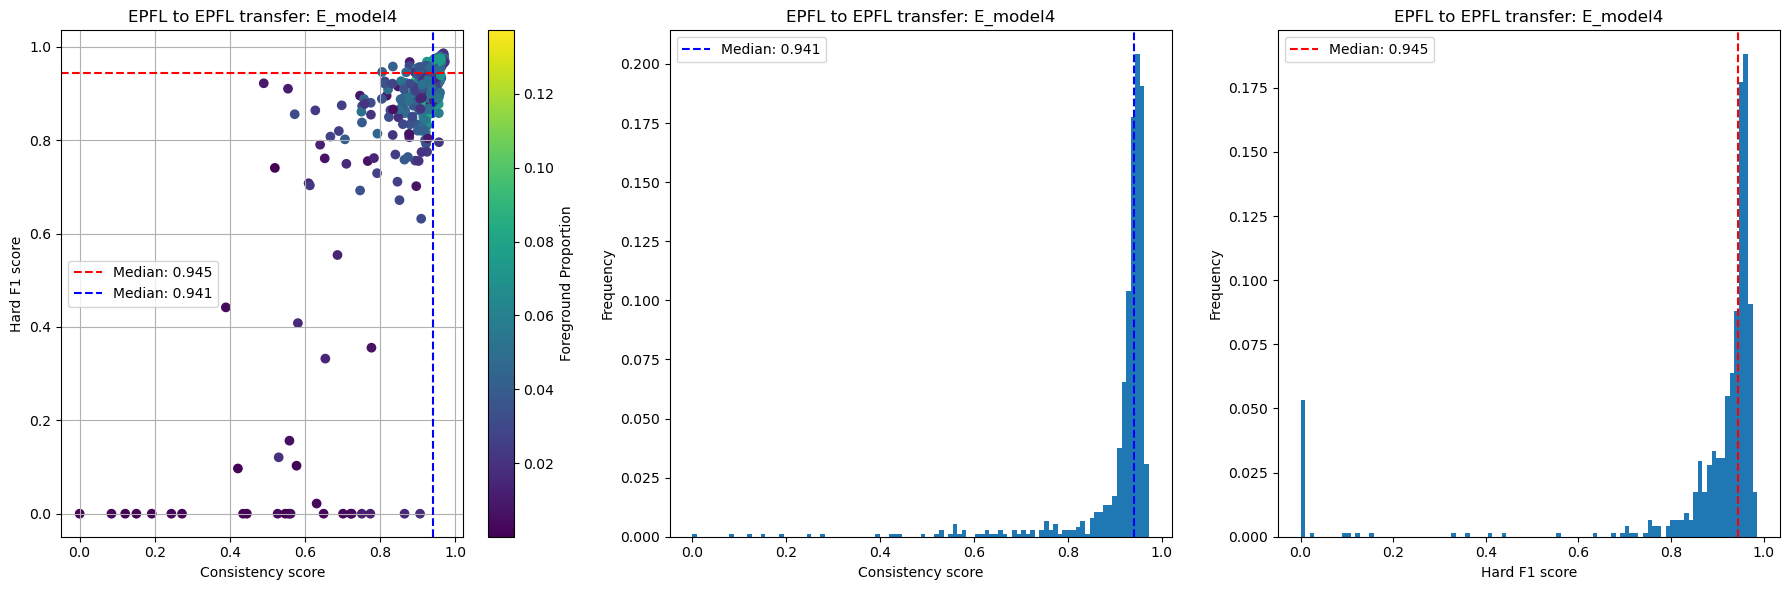

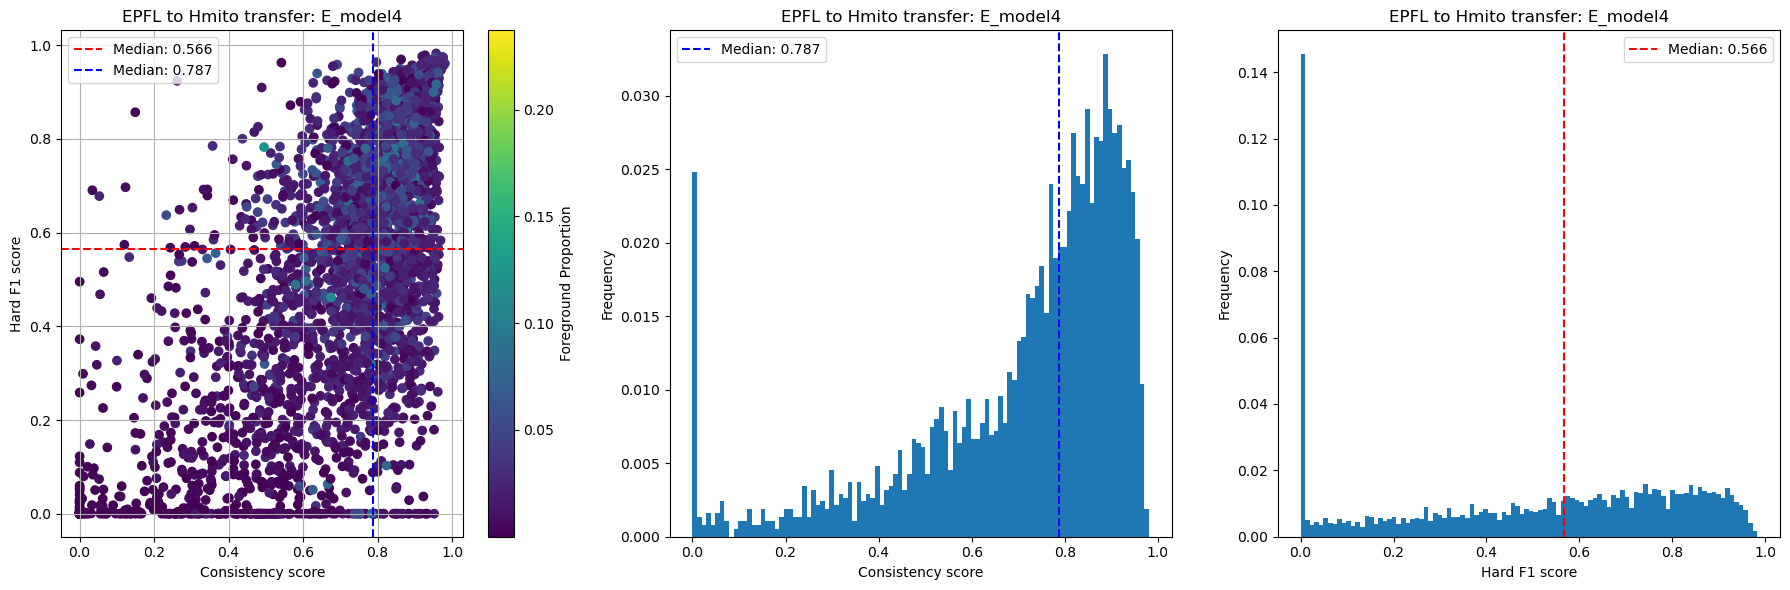

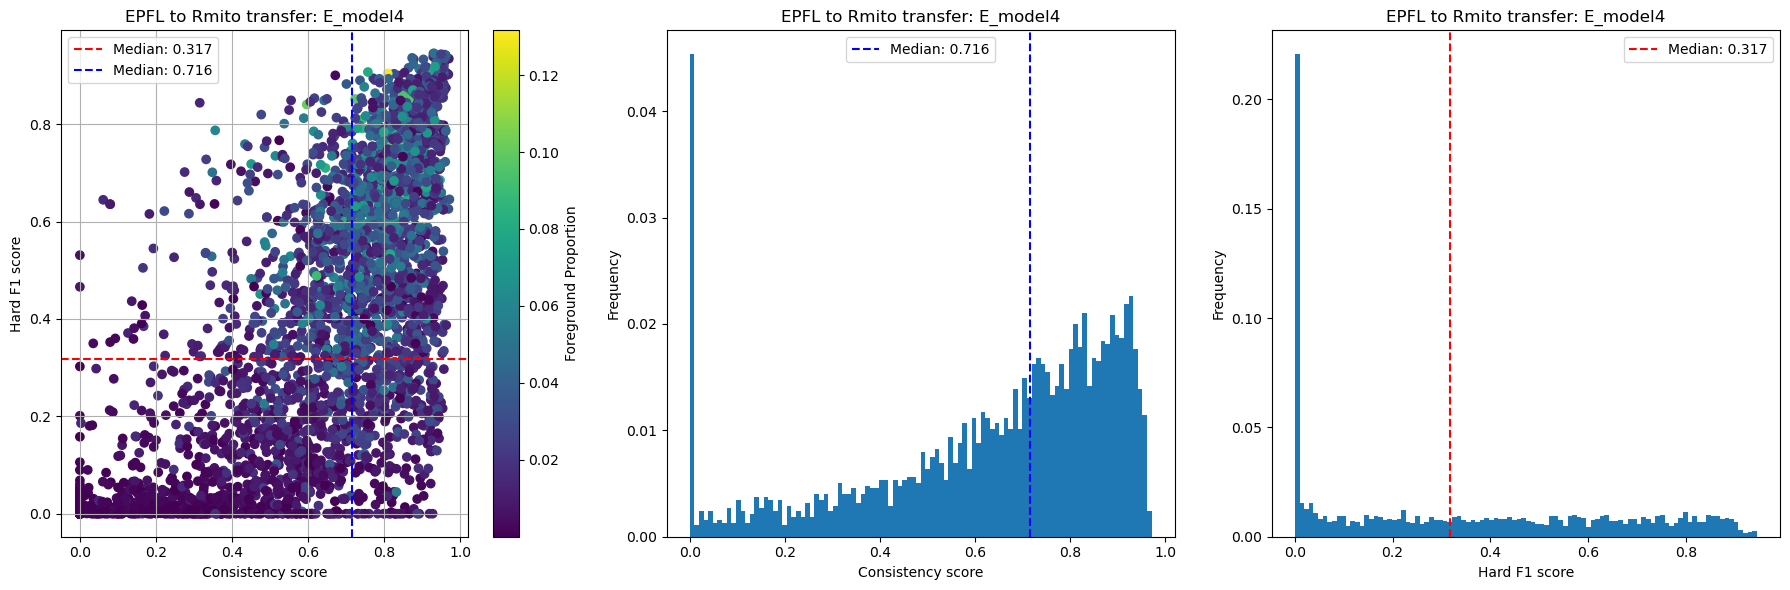

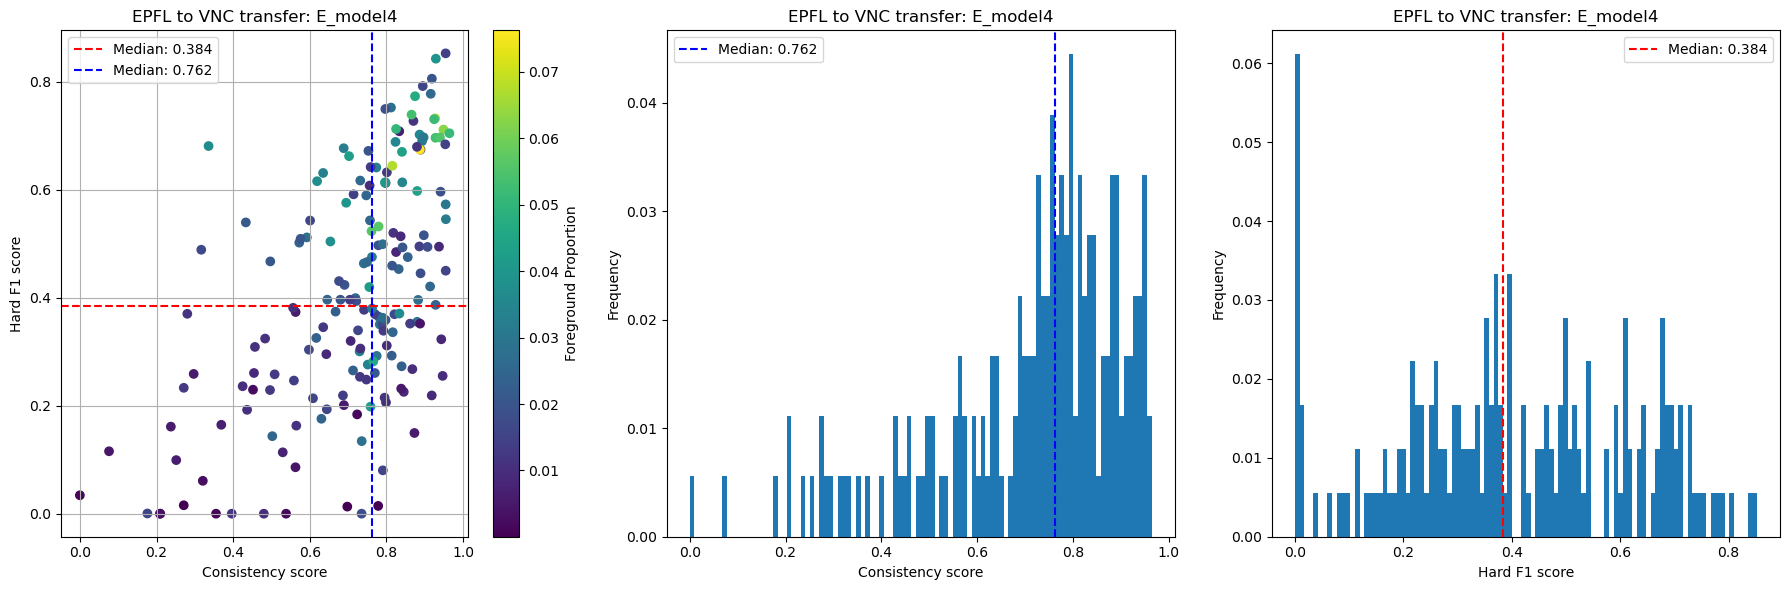

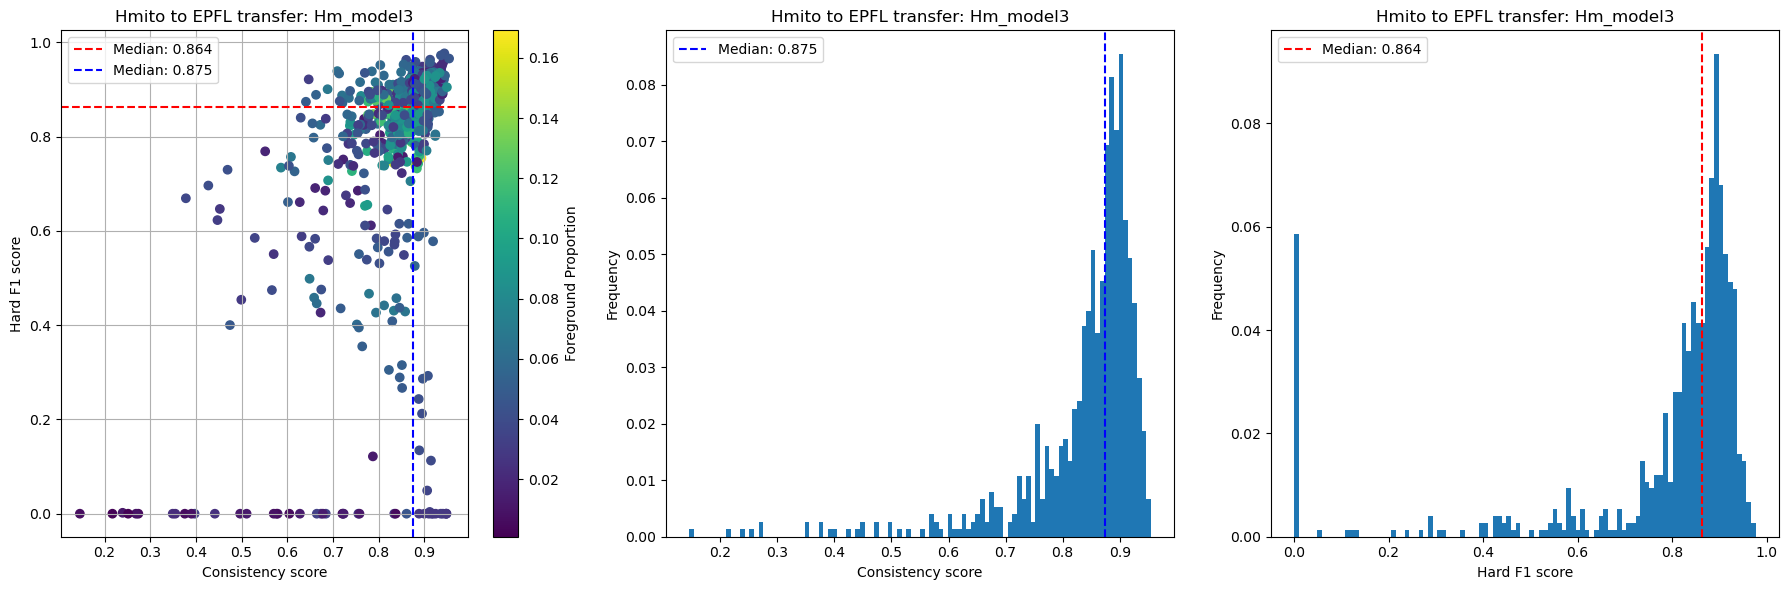

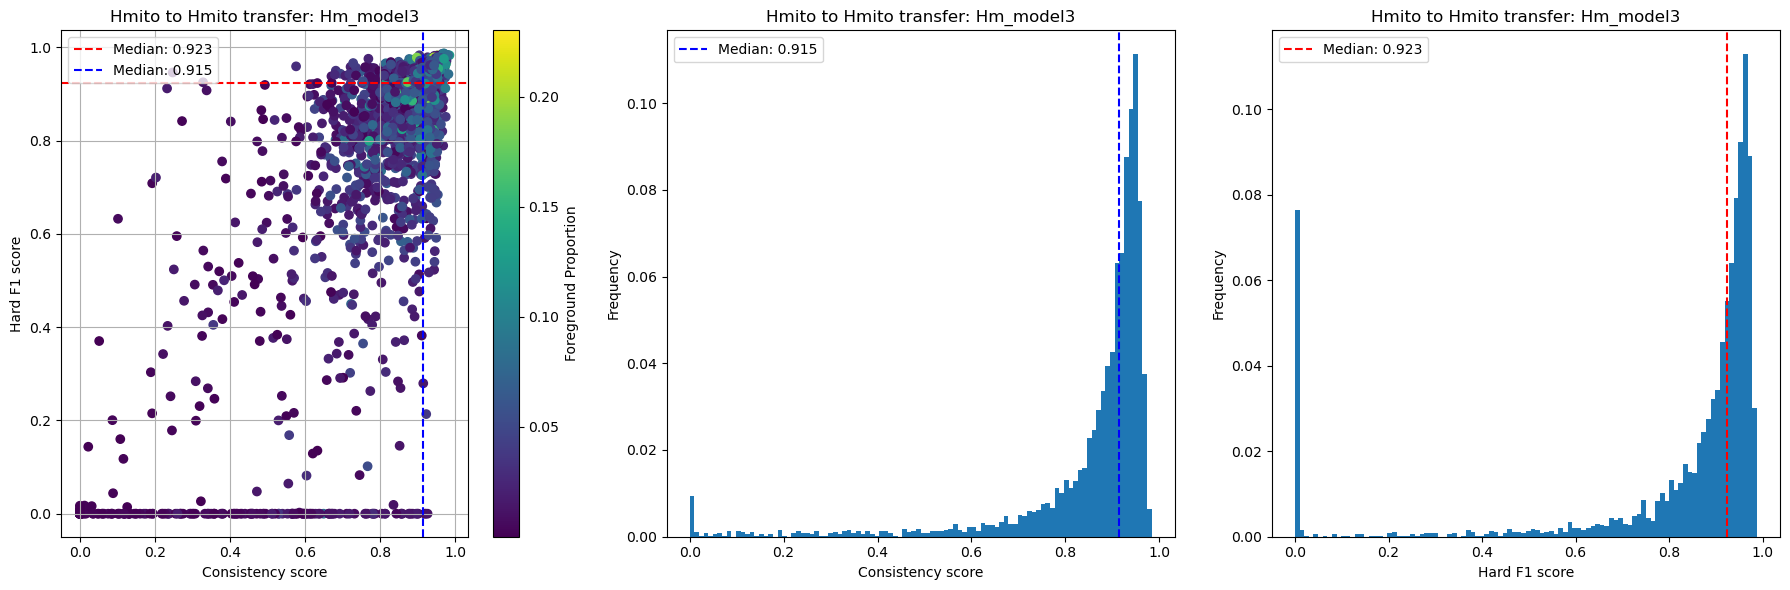

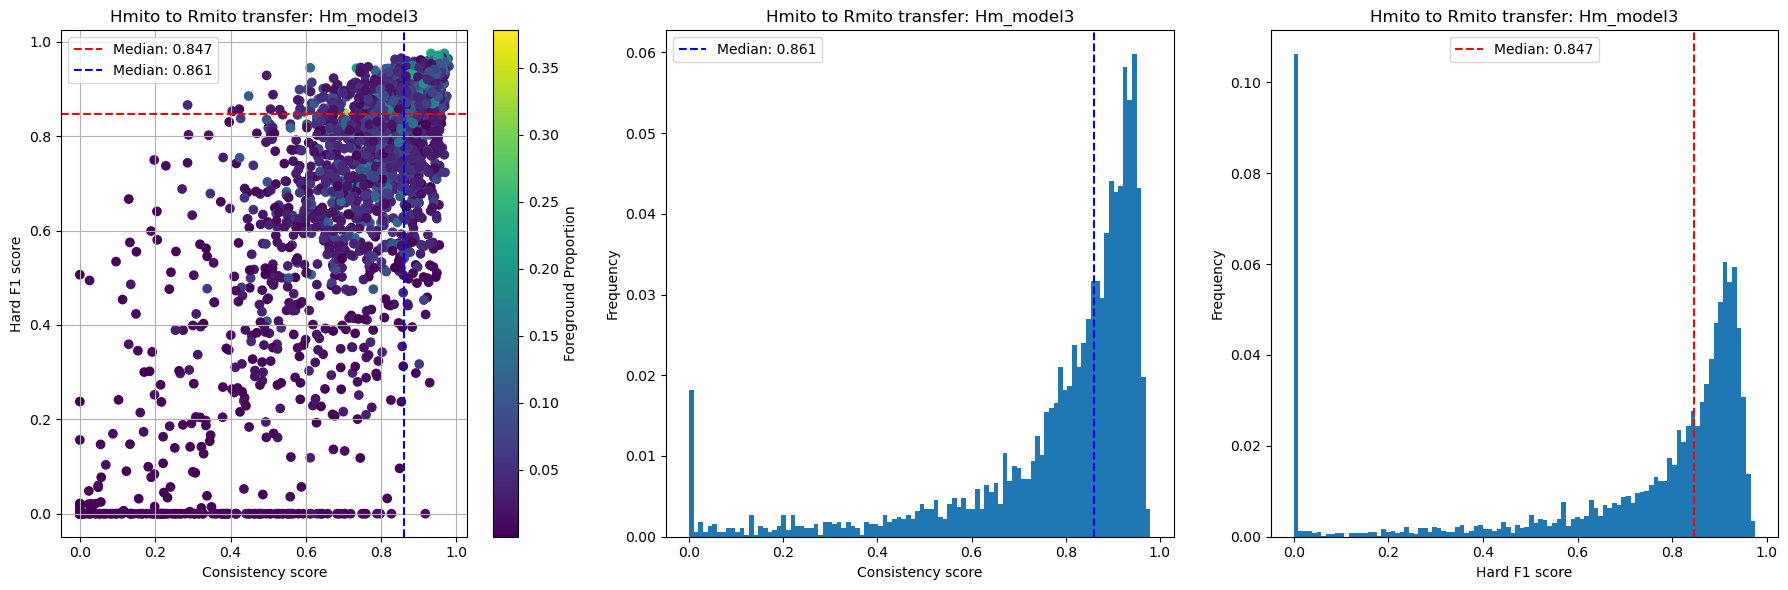

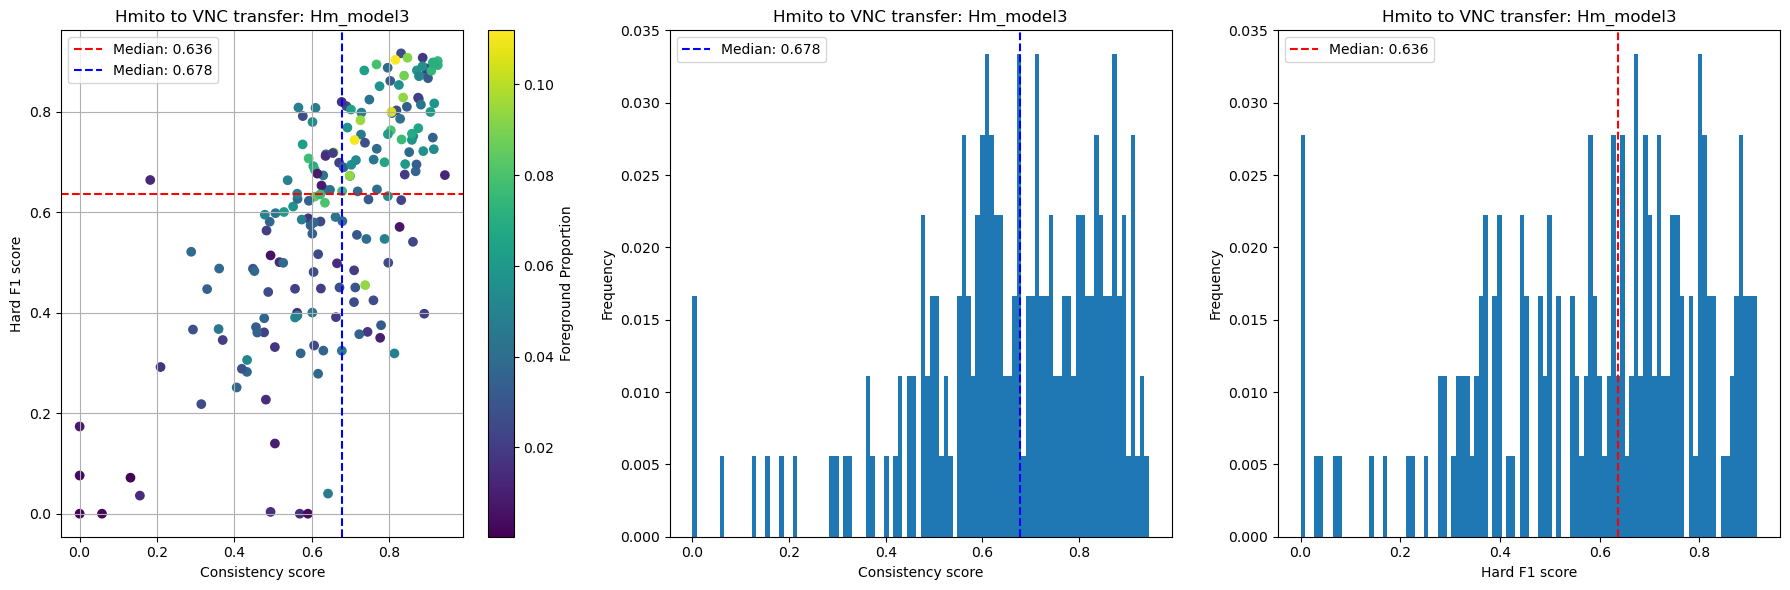

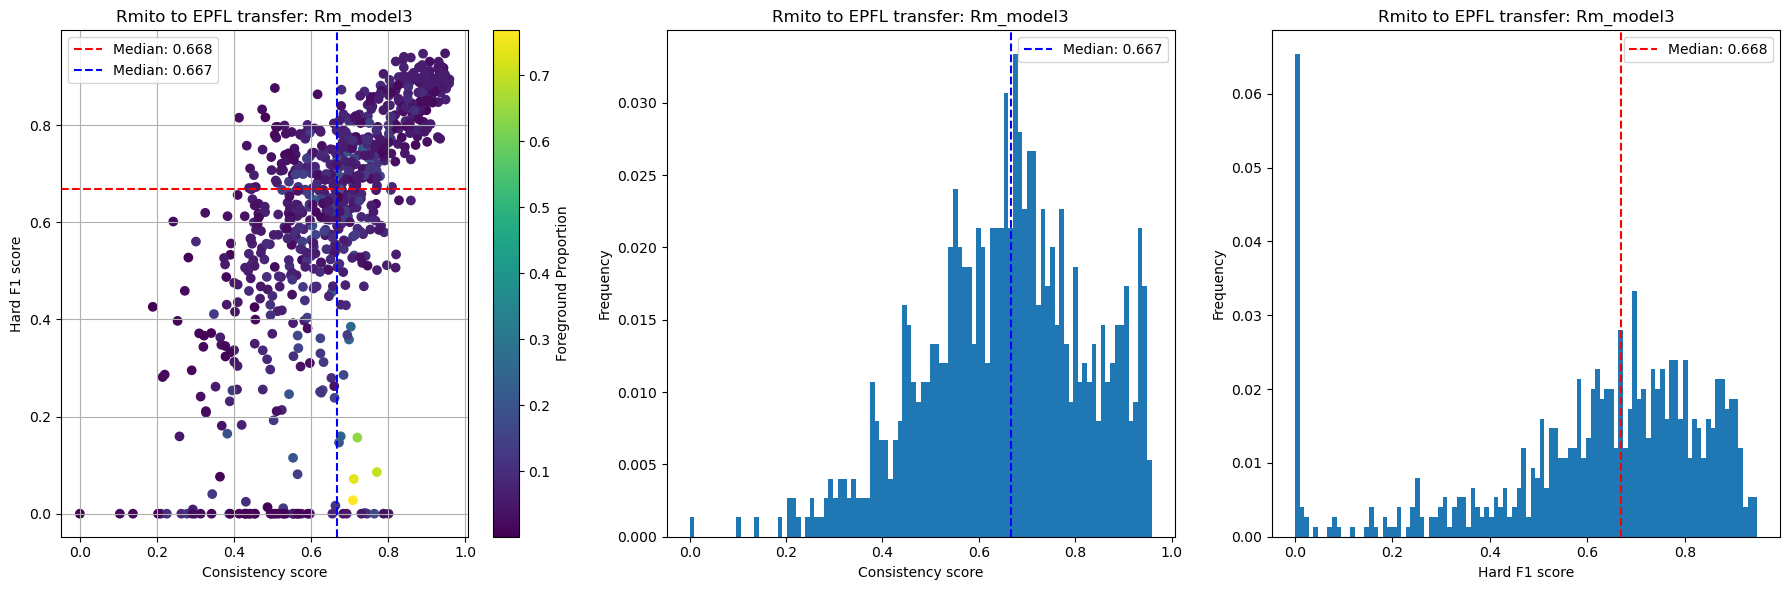

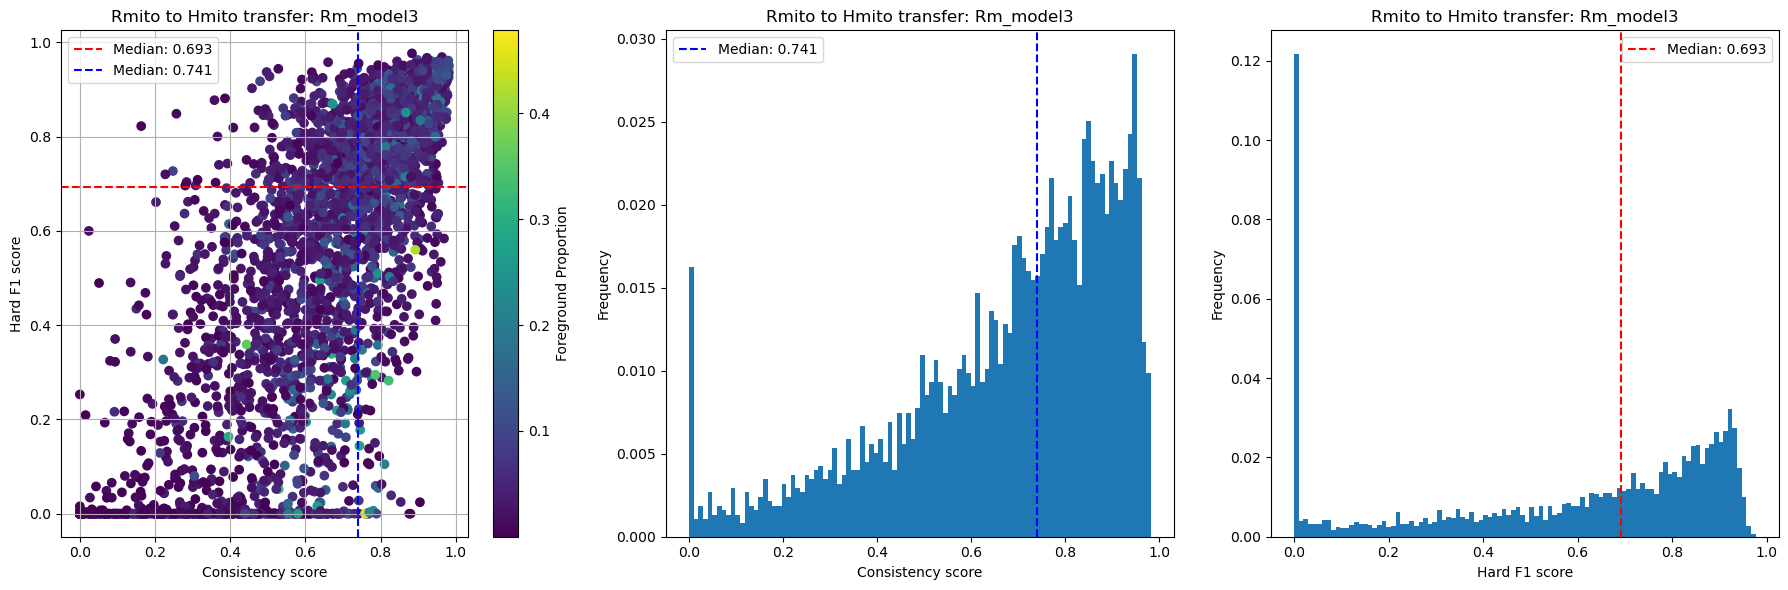

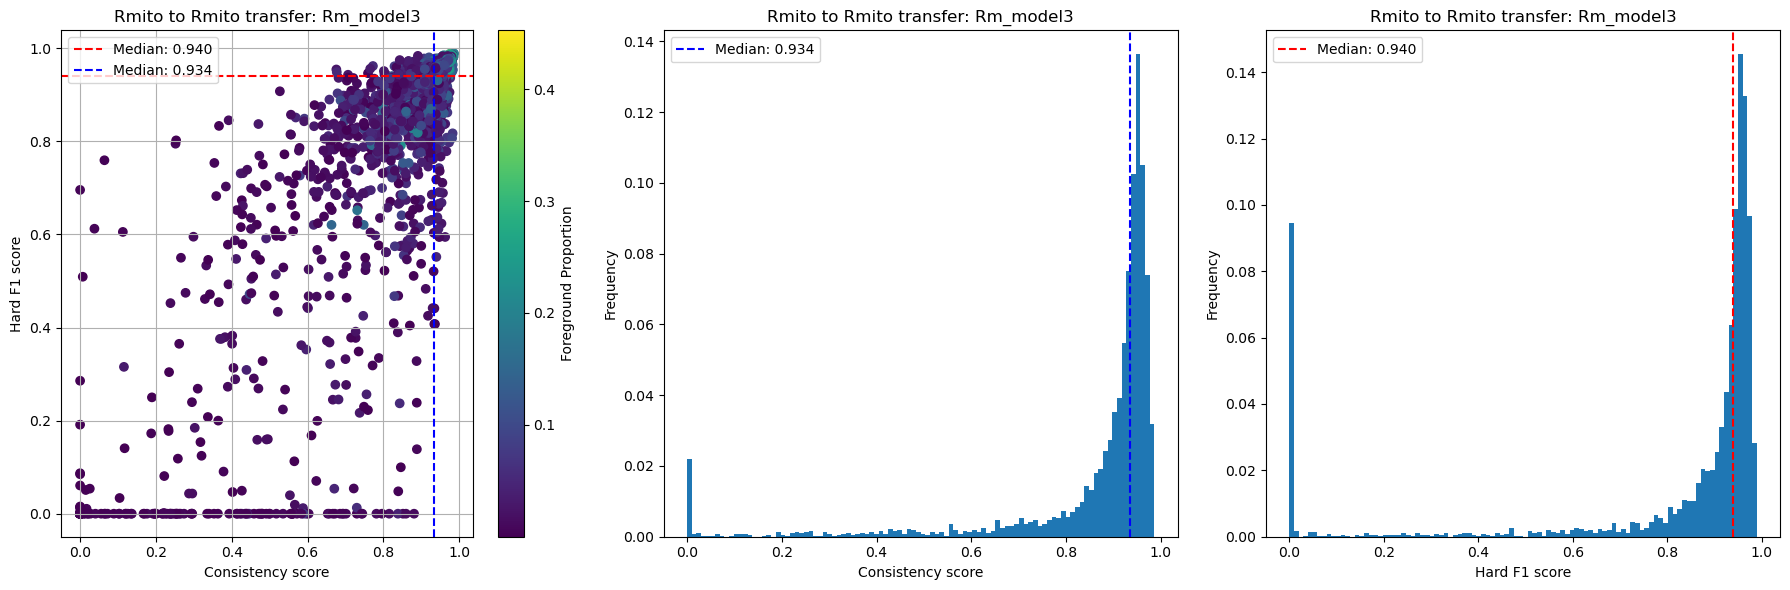

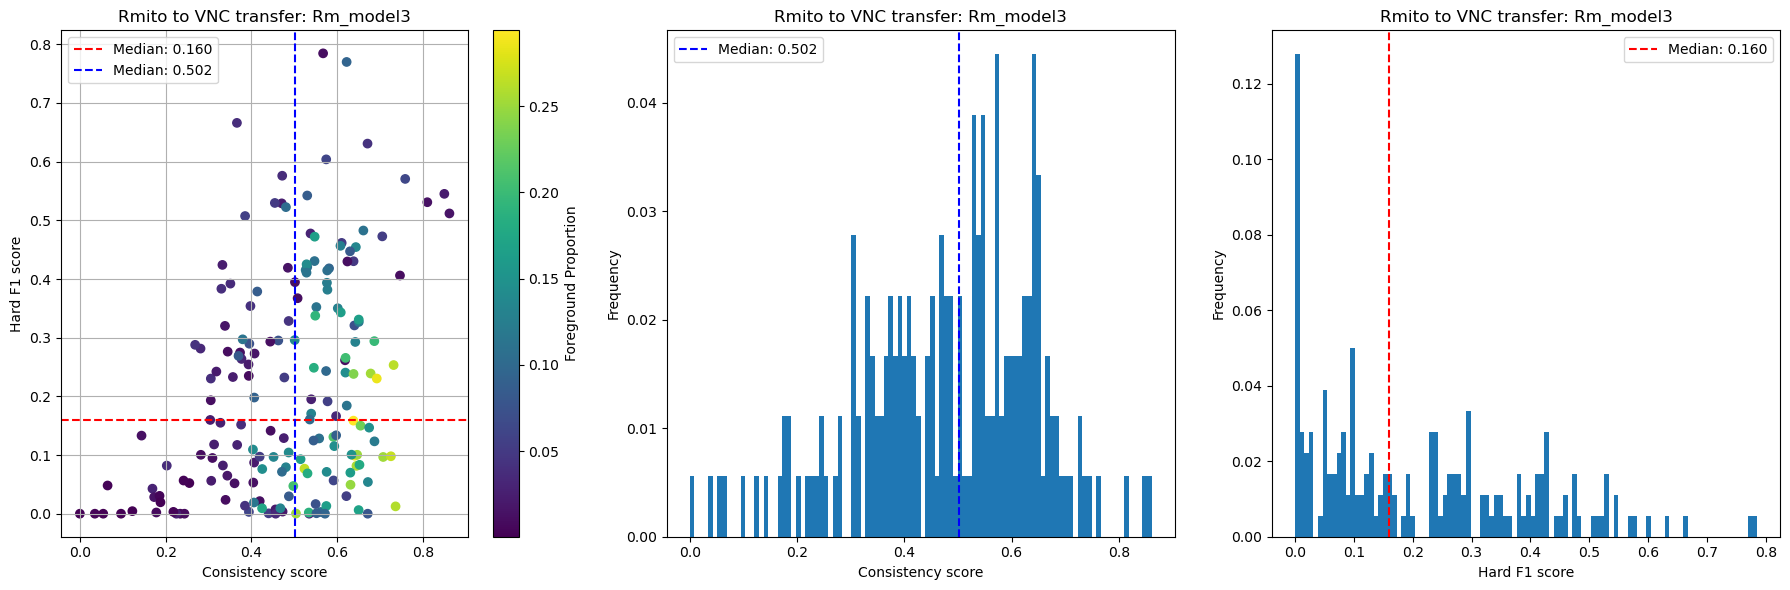

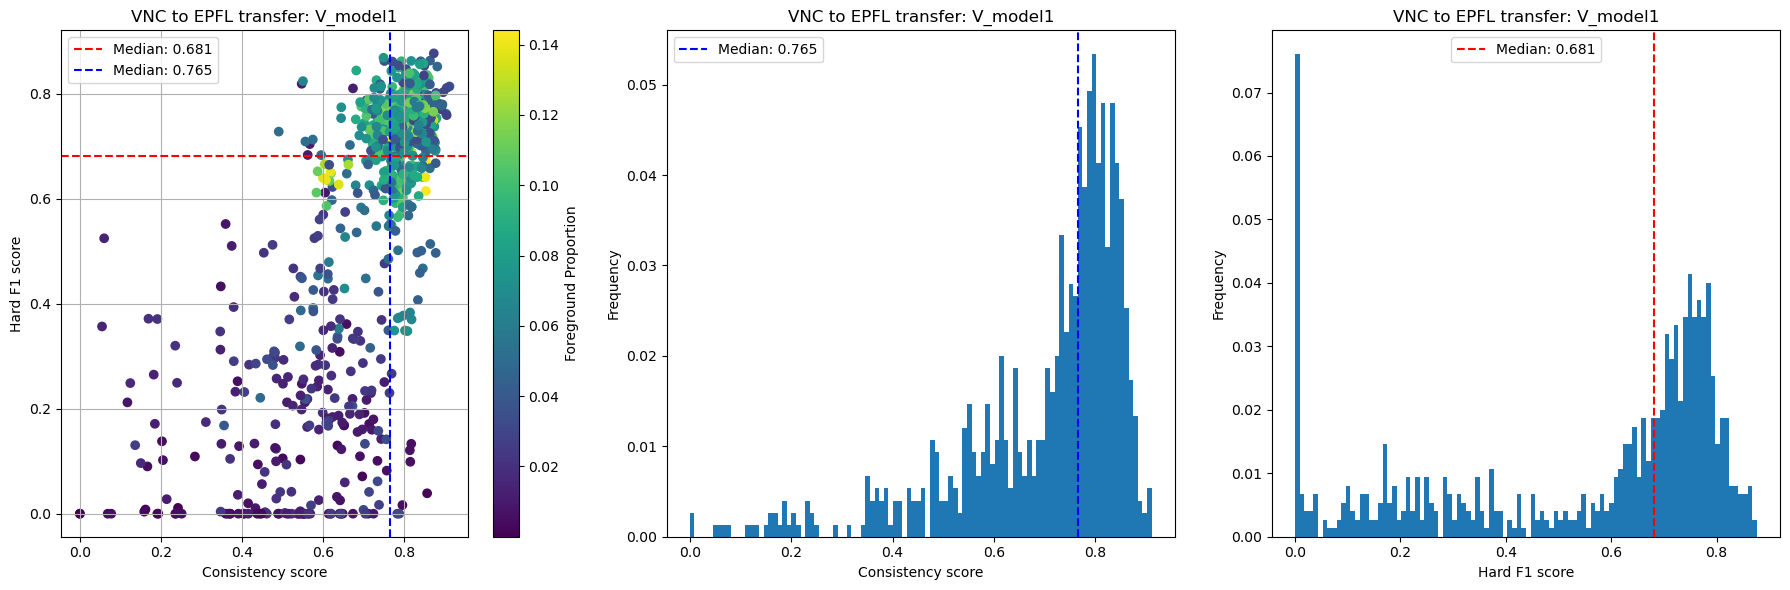

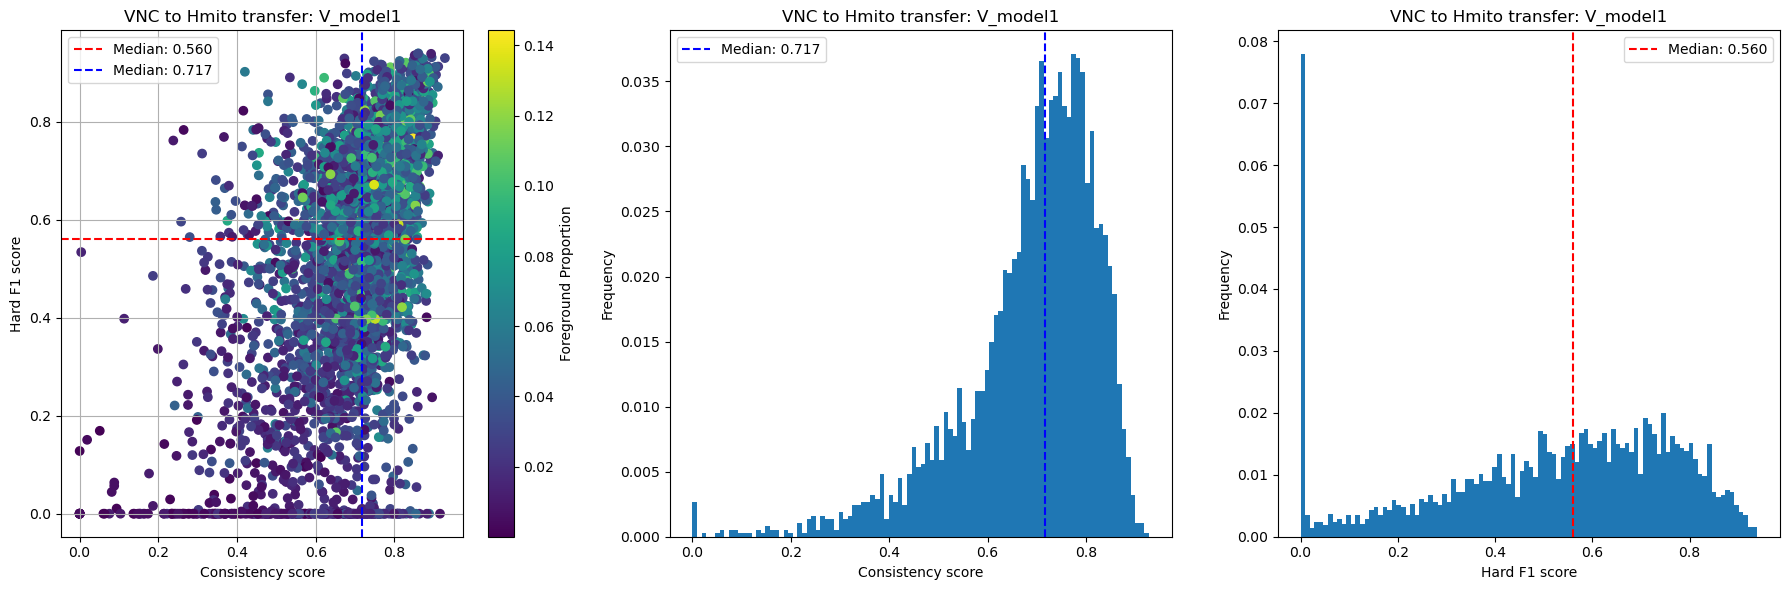

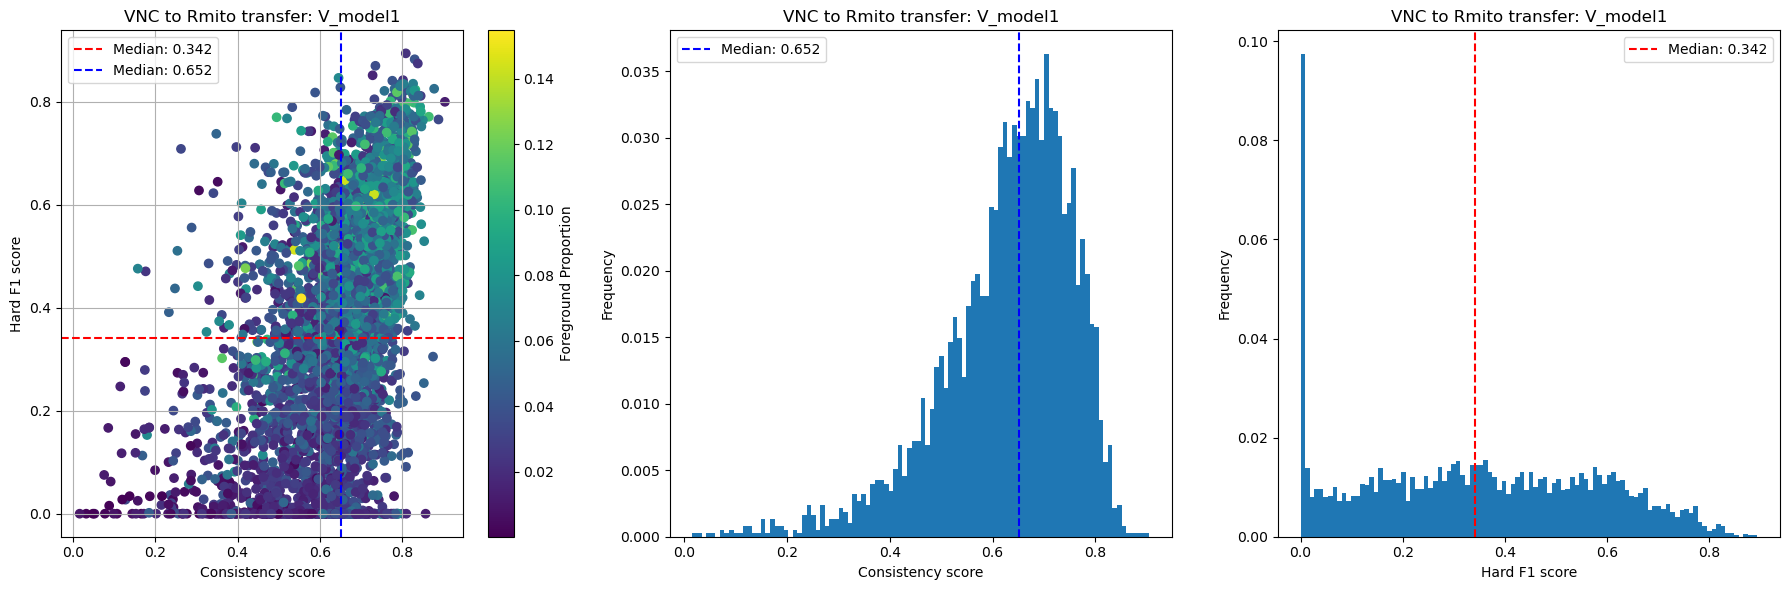

In [21]:
sources = {
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["VNC"]



for source, model_name in sources.items():
    for target in targets:
        if target == "VNC":
            if source == "VNC":
                continue
            result_folder = "resized"
            consis_key = "EI_consis"
            
        else:
            result_folder = "FP_3"
            if source == "VNC":
                consis_key = "EI_consis"
            else:
                consis_key = "EI_th05"
        none_paths = get_output_paths(
            source, 
            target, 
            {"none": []}, 
            [None], 
            model_name, 
            "predictions", 
            result_folder =result_folder, 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        DO_paths = get_output_paths(
            source, 
            target, 
            {"DO": ["a02"]}, 
            [None], 
            model_name, 
            "predictions", 
            result_folder =result_folder, 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(none_paths) == 1, f"Expected one path for {source} to {target} transfer: {model_name}, found {len(paths)}"
        direct_pred_path: List[Path] = list(Path(none_paths[0]).glob("*.h5"))
        DO_pred_path: List[Path] = list(Path(DO_paths[0]).glob("*.h5"))
        for i in range(len(direct_pred_path)):
            if "metric_summary" in direct_pred_path[i].name:
                _ = direct_pred_path.pop(i)
            if "metric_summary" in DO_pred_path[i].name:
                _ = DO_pred_path.pop(i)
        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")[:,1]
        consis_score_direct = load_h5(DO_pred_path[0], consis_key)
        consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))
        eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
        consis_median = np.nanmedian(consis_score_PP, axis=0)
        foreground_proportions = np.count_nonzero(~np.isnan(consis_score_direct), axis=(1,2))/consis_score_direct[0].size
        _, axs = plt.subplots(1, 3, figsize=(18, 6))
        sc = axs[0].scatter(consis_score_PP, eval_score_direct, c=foreground_proportions, cmap='viridis')
        _ = axs[0].set_xlabel("Consistency score")
        plt.colorbar(sc, ax=axs[0], label='Foreground Proportion')
        _ = axs[0].set_ylabel("Hard F1 score")
        _ = axs[0].grid()
        _ = axs[0].set_title(f"{source} to {target} transfer: {model_name}")
        _ = axs[0].axhline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
        _ = axs[0].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
        _ = axs[0].legend()
        _ = axs[1].hist(consis_score_PP, bins=100, weights=np.ones_like(consis_score_PP) / len(consis_score_PP))
        _ = axs[1].set_title(f"{source} to {target} transfer: {model_name}")
        _ = axs[1].set_xlabel("Consistency score")
        _ = axs[1].set_ylabel("Frequency")
        _ = axs[1].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
        _ = axs[1].legend()
        _ = axs[2].hist(eval_score_direct, bins=100, weights=np.ones_like(eval_score_direct) / len(eval_score_direct))
        _ = axs[2].axvline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
        _ = axs[2].legend()
        _ = axs[2].set_title(f"{source} to {target} transfer: {model_name}")
        _ = axs[2].set_xlabel("Hard F1 score")
        _ = axs[2].set_ylabel("Frequency")
        plt.tight_layout()
        plt.show()
        

# Filter Patches based on predicted Foreground ratio

/tmp/ipykernel_2863152/3437998236.py:61: RuntimeWarning: Mean of empty slice
  consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))


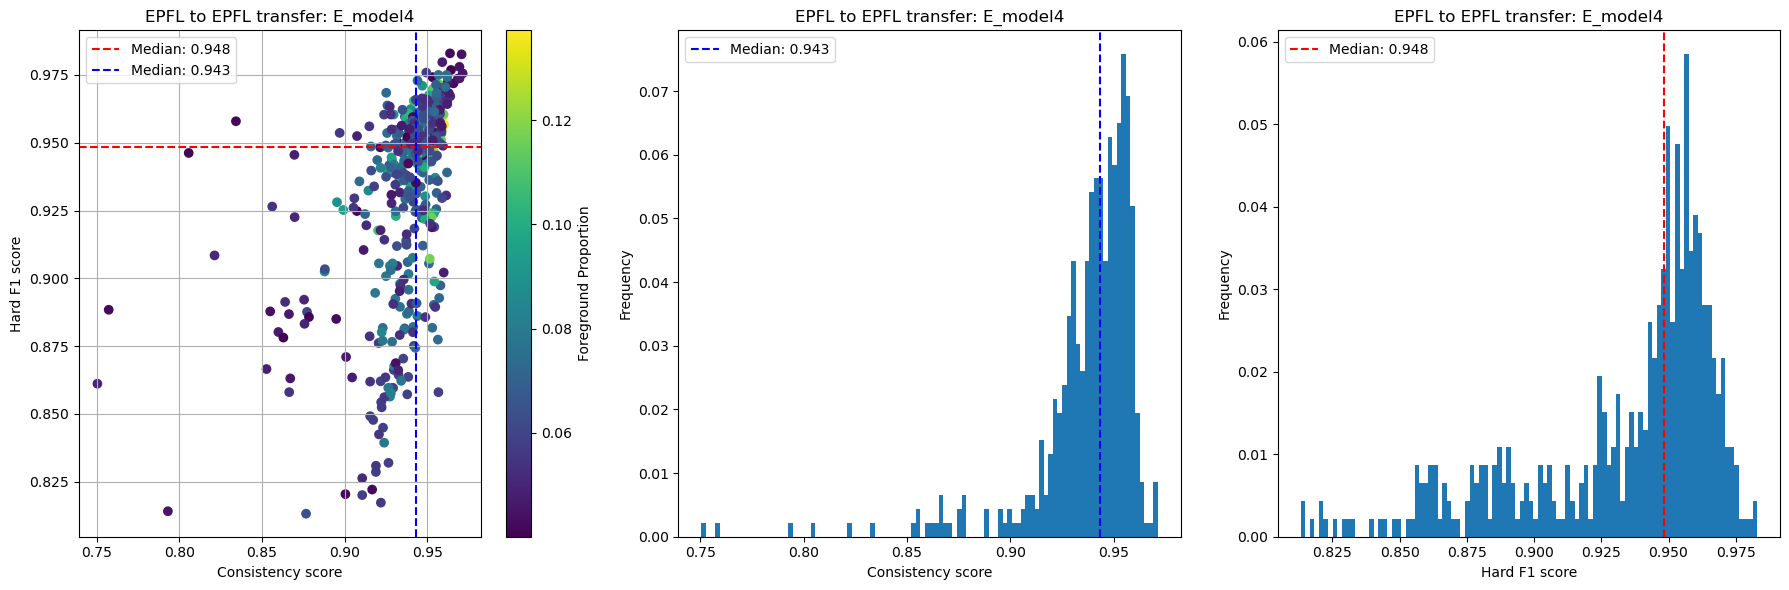

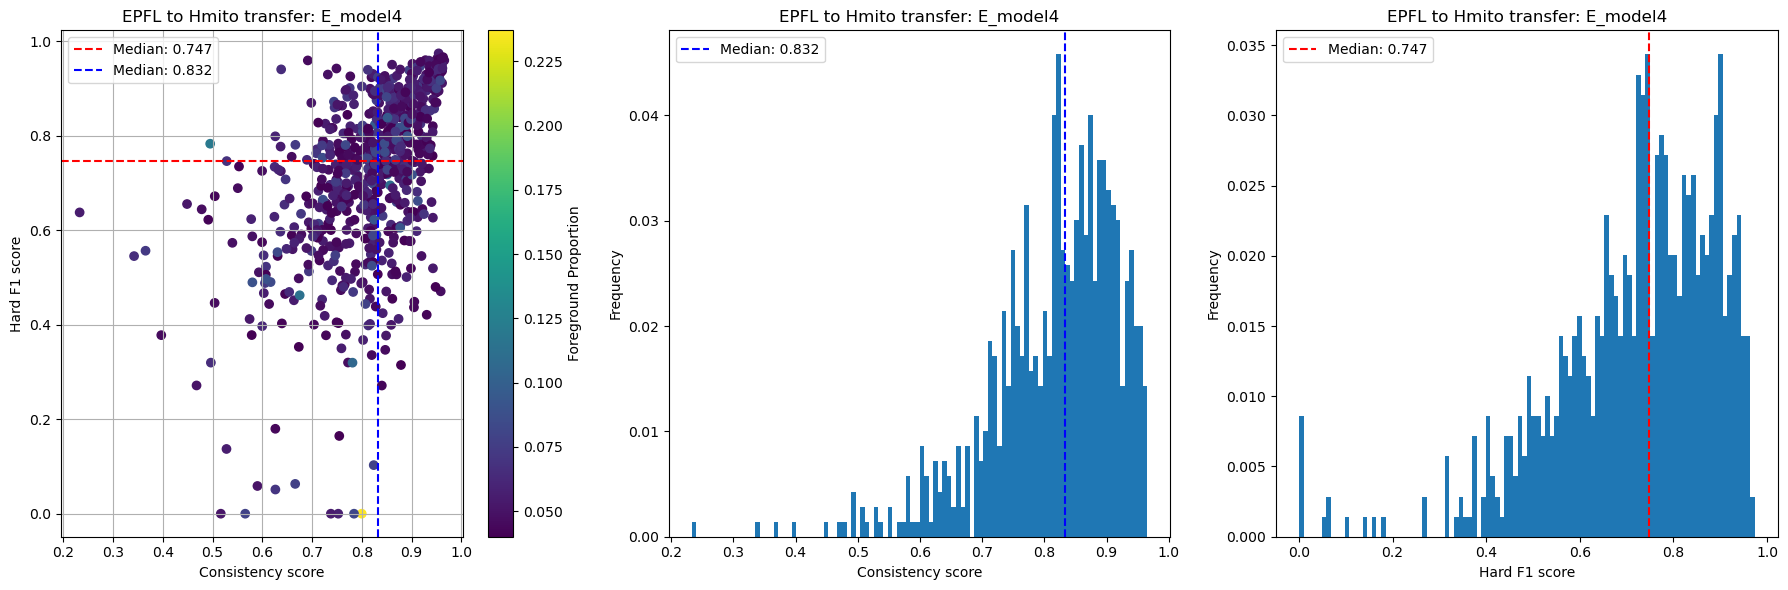

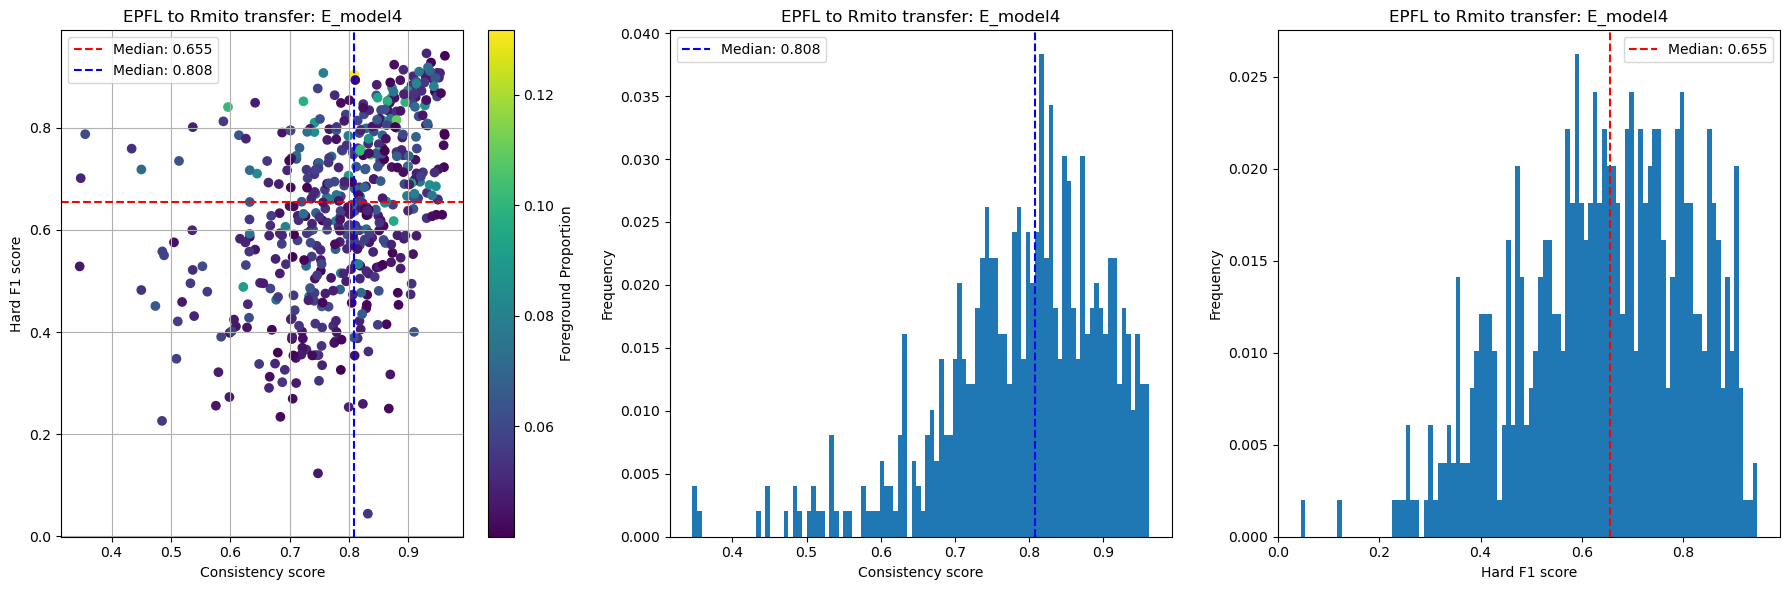

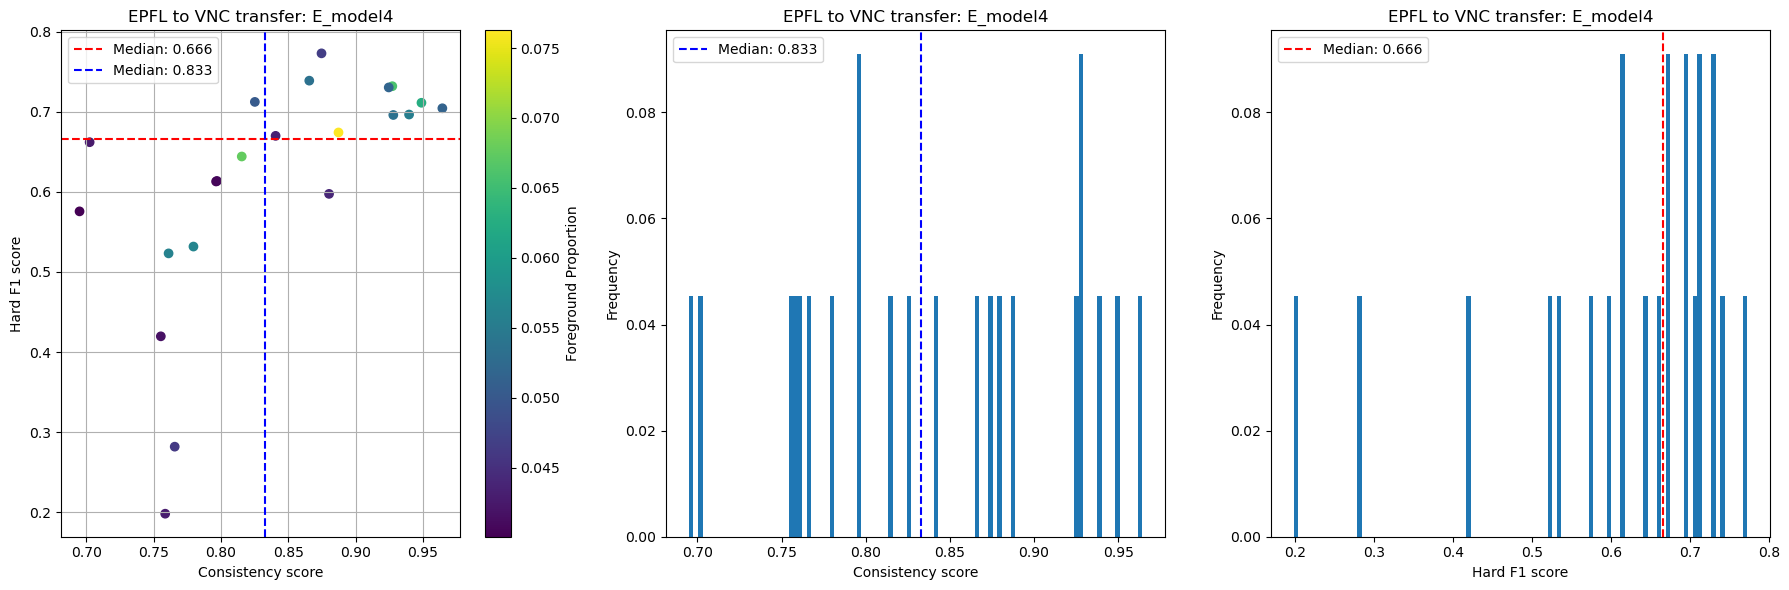

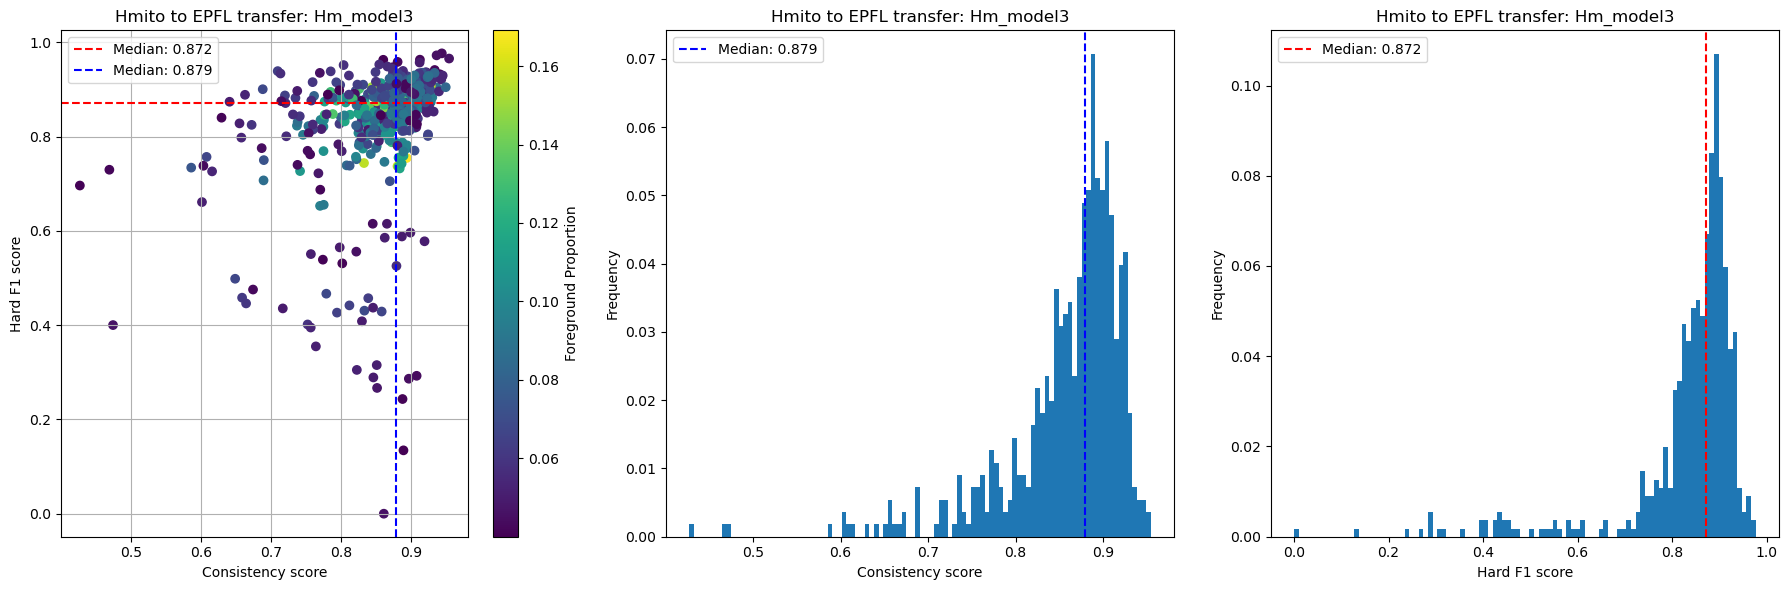

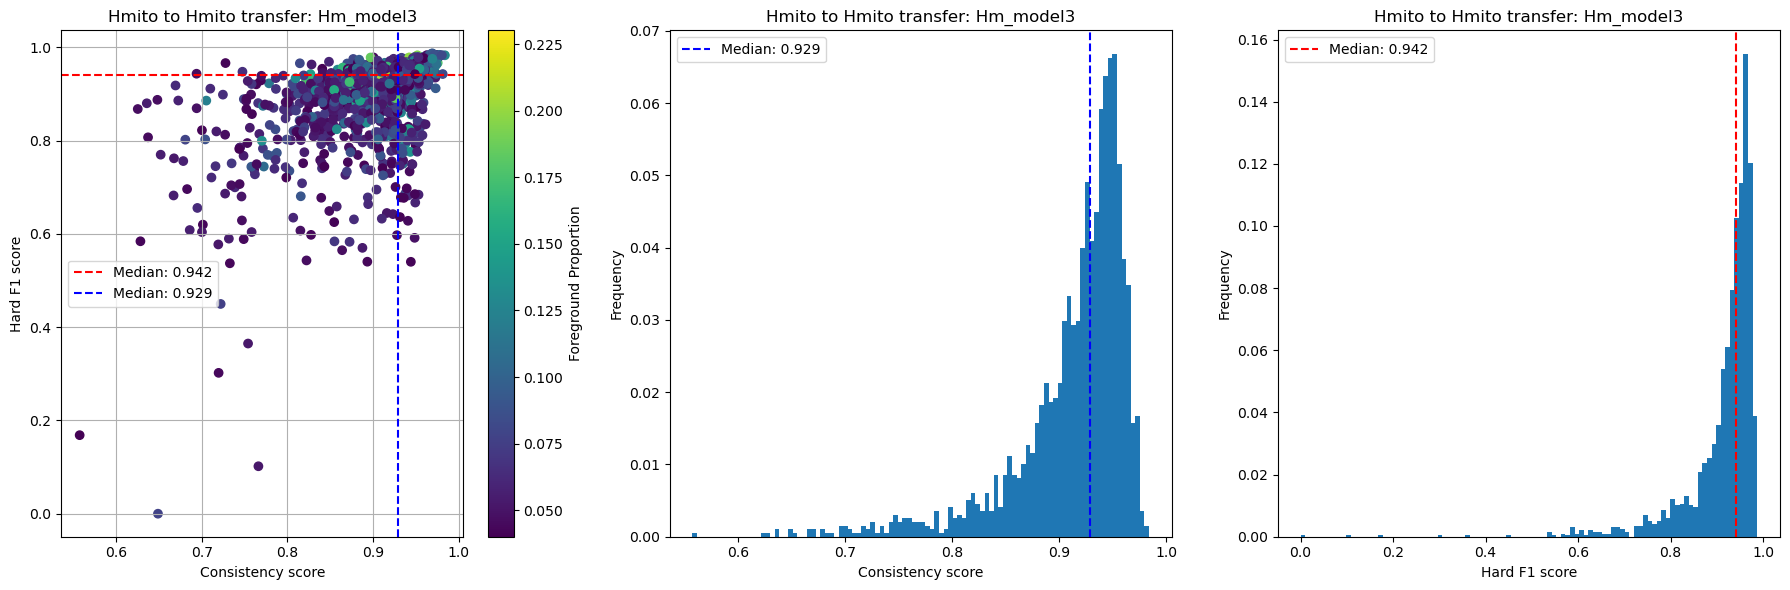

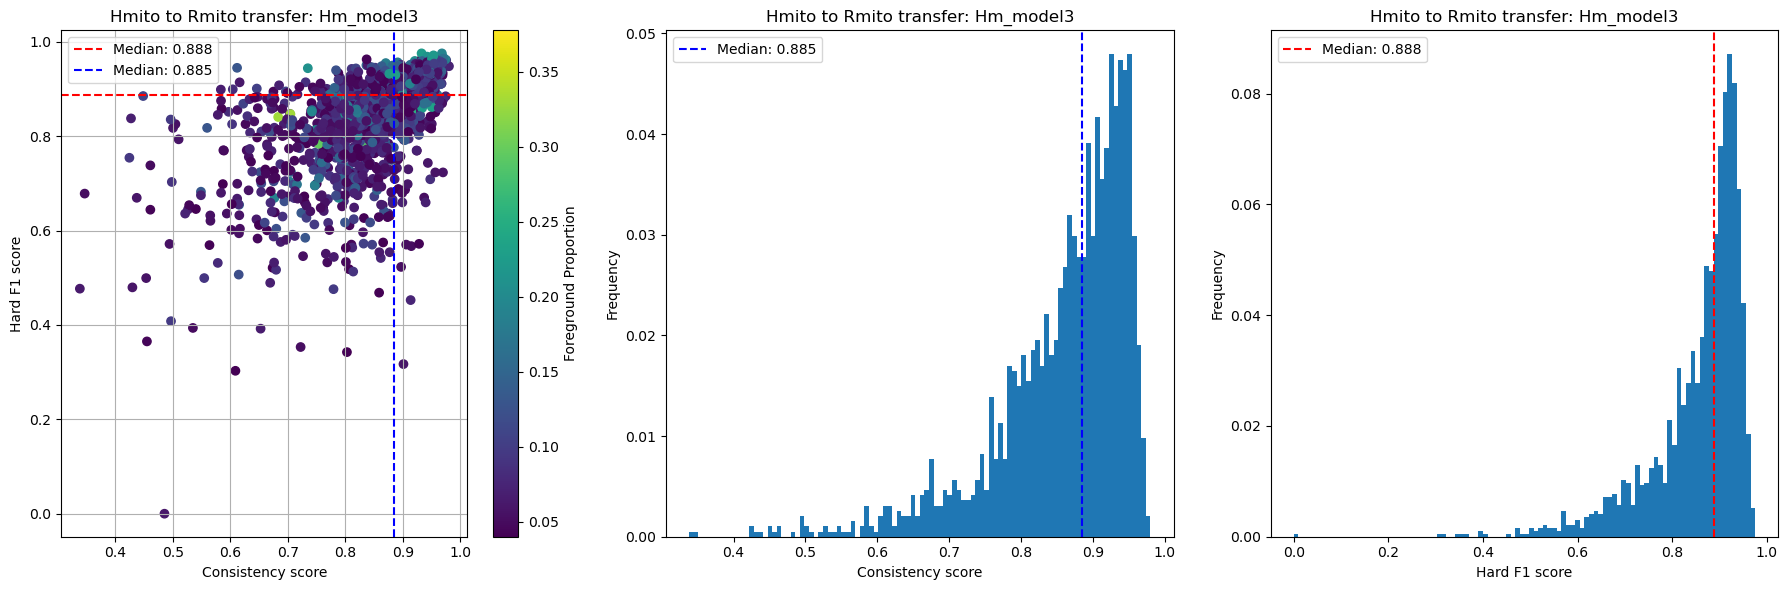

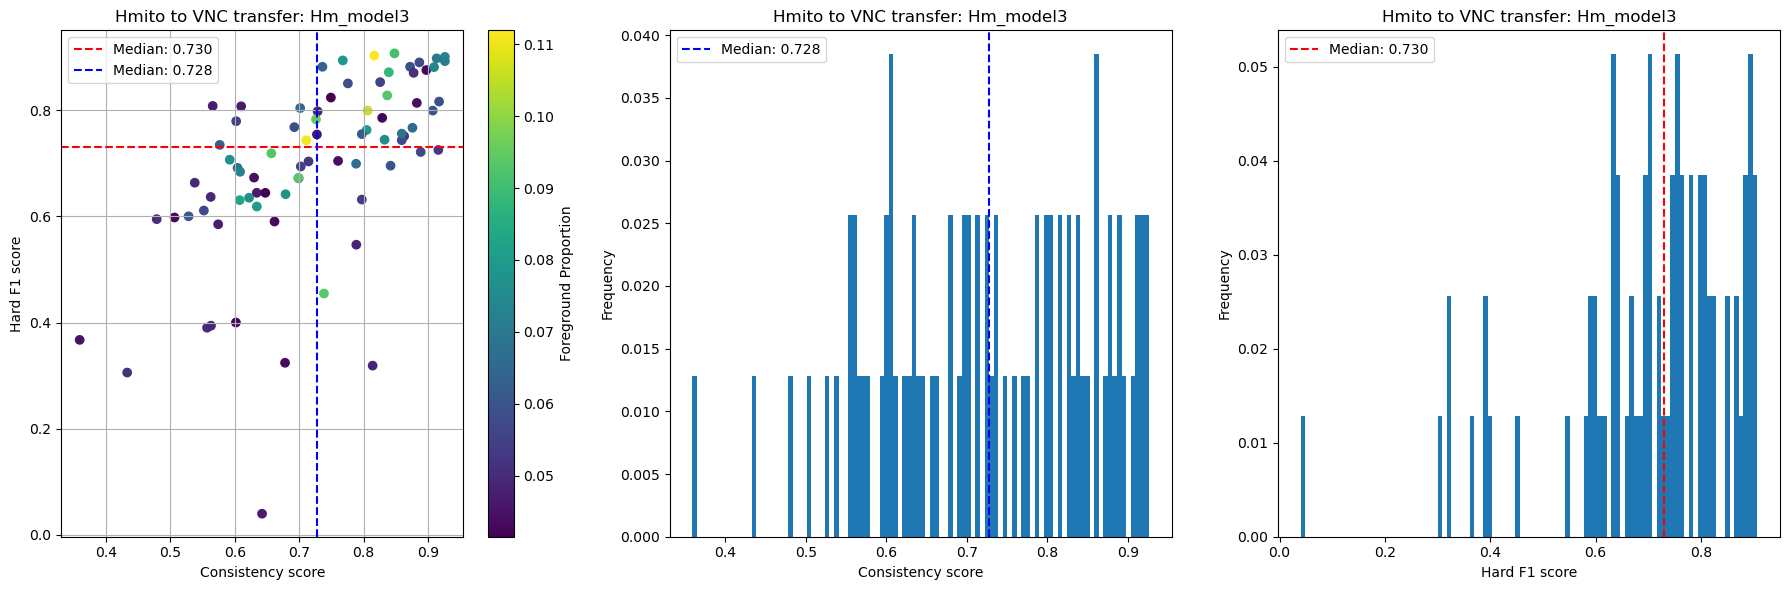

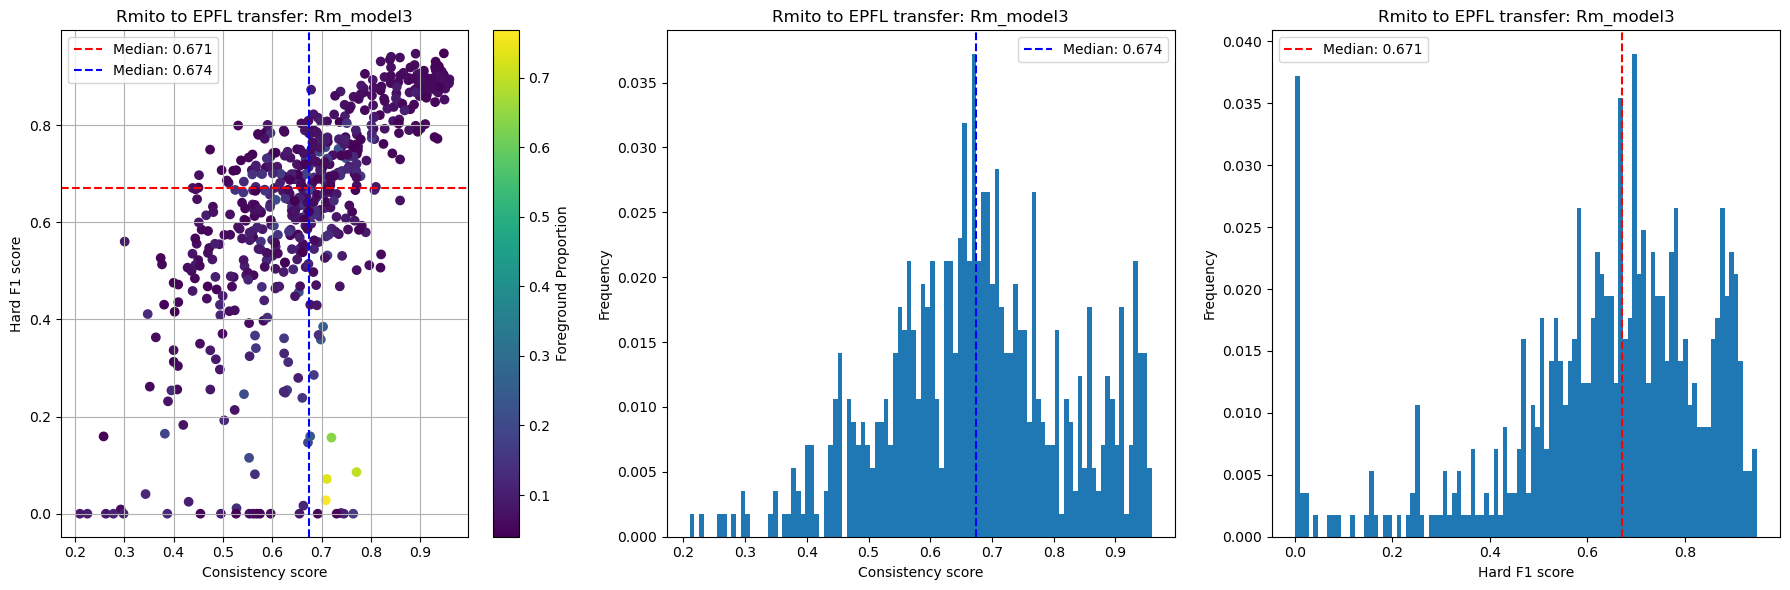

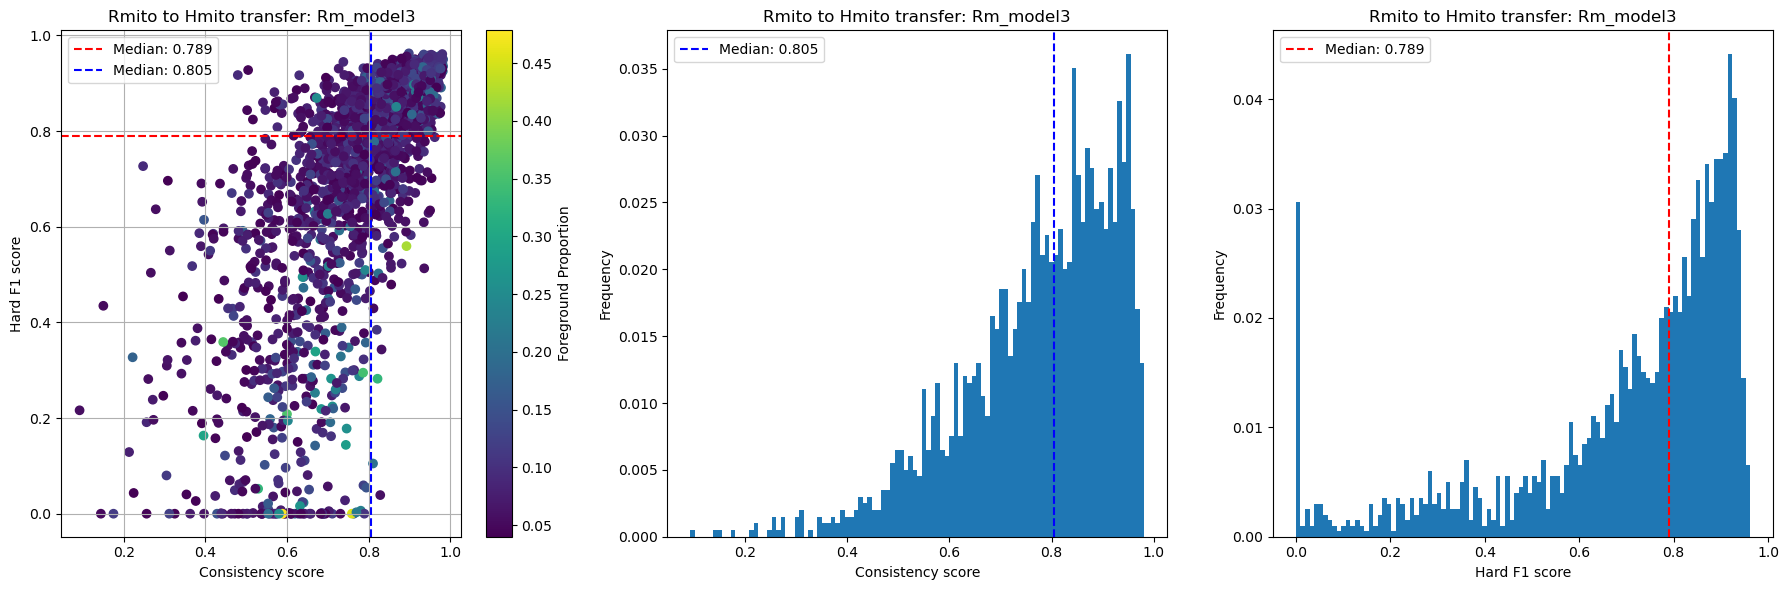

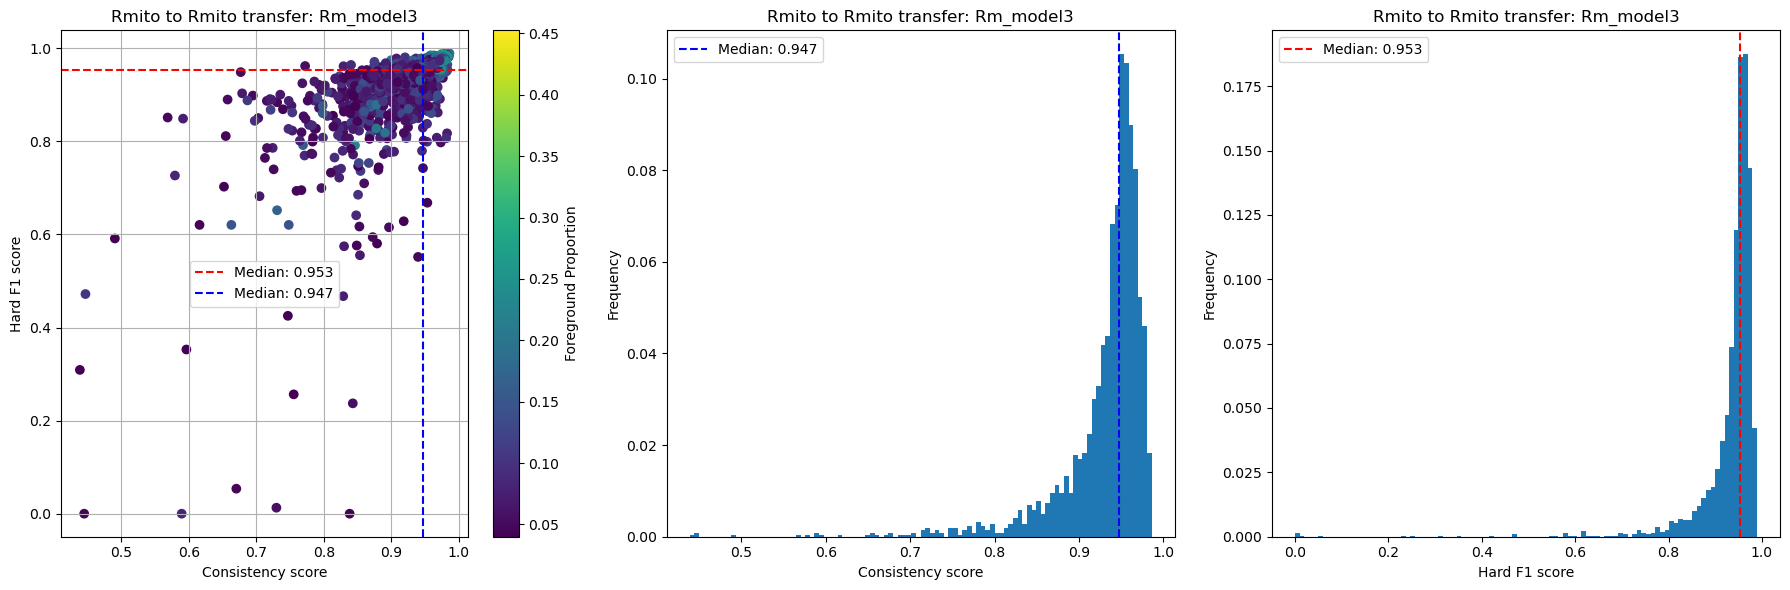

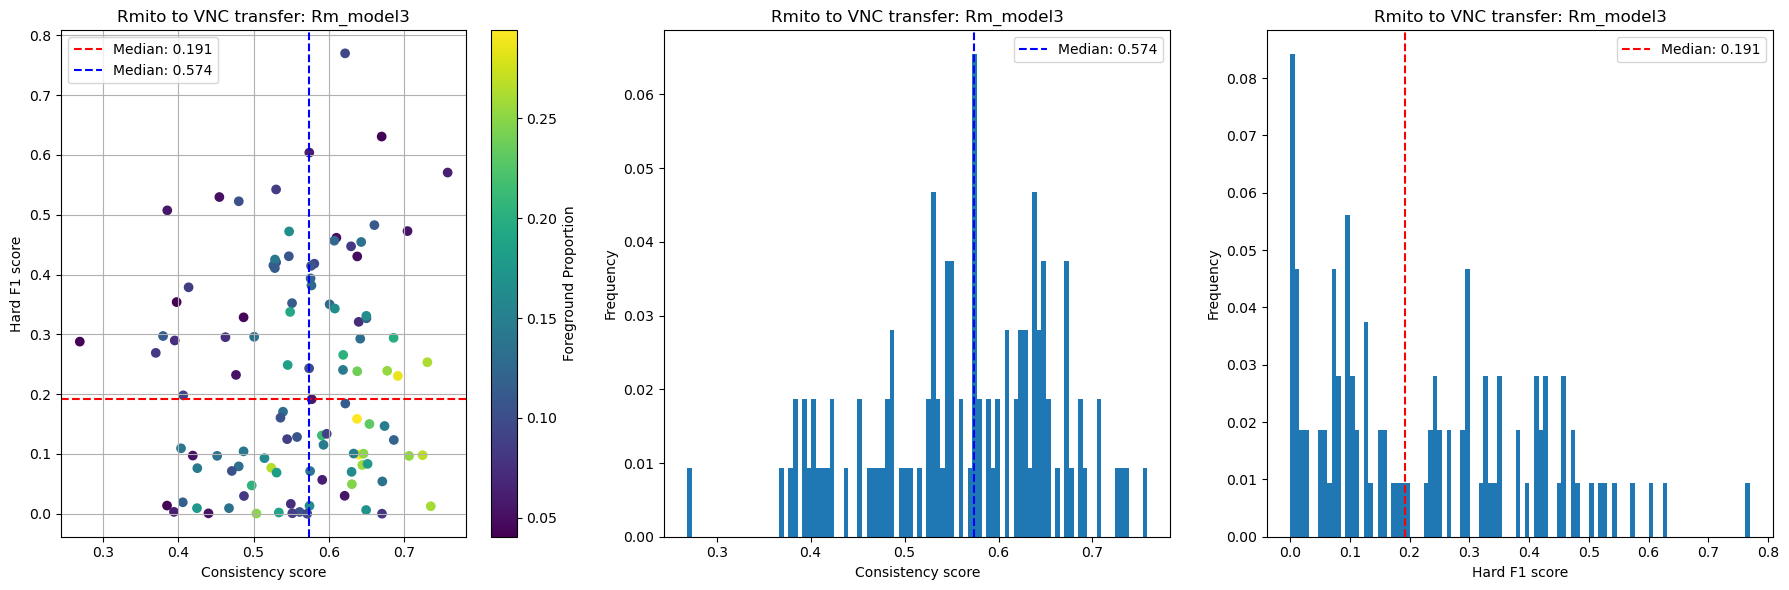

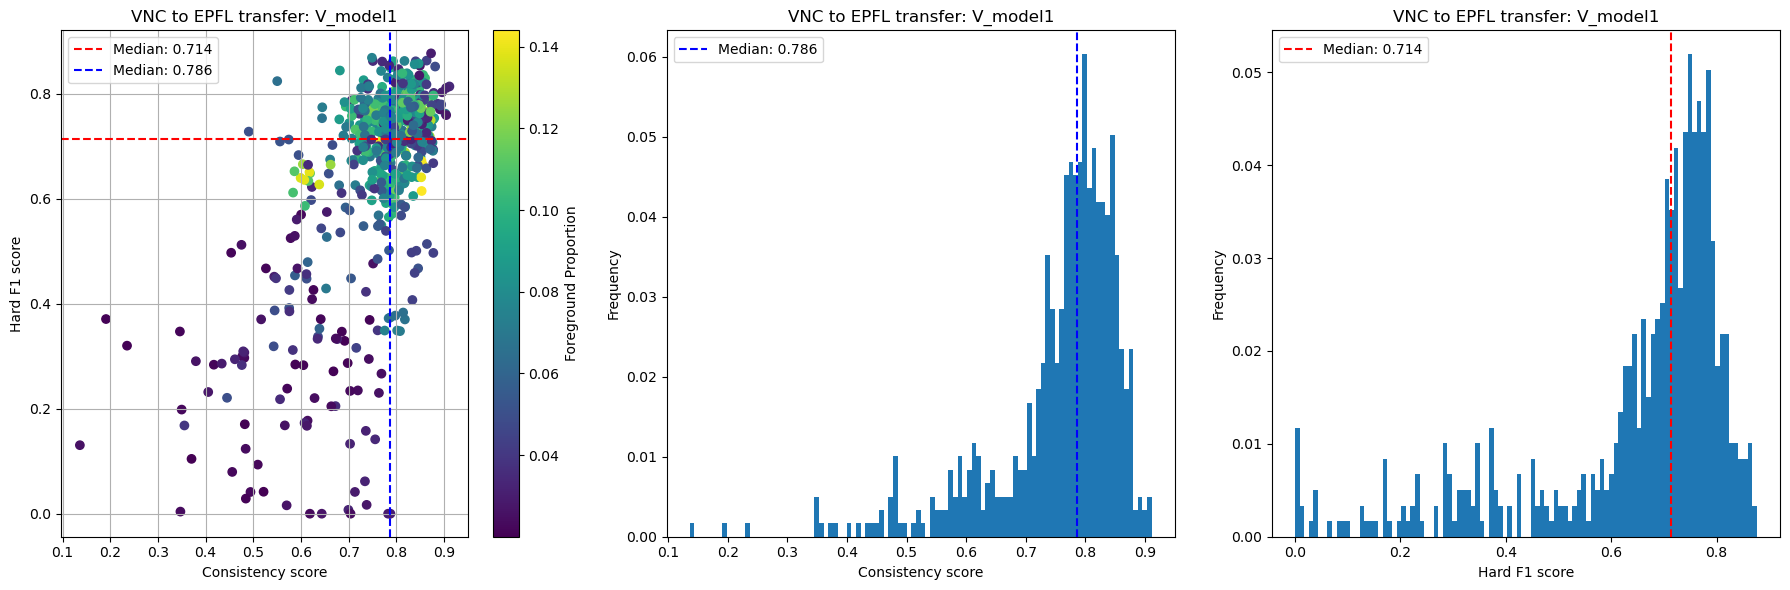

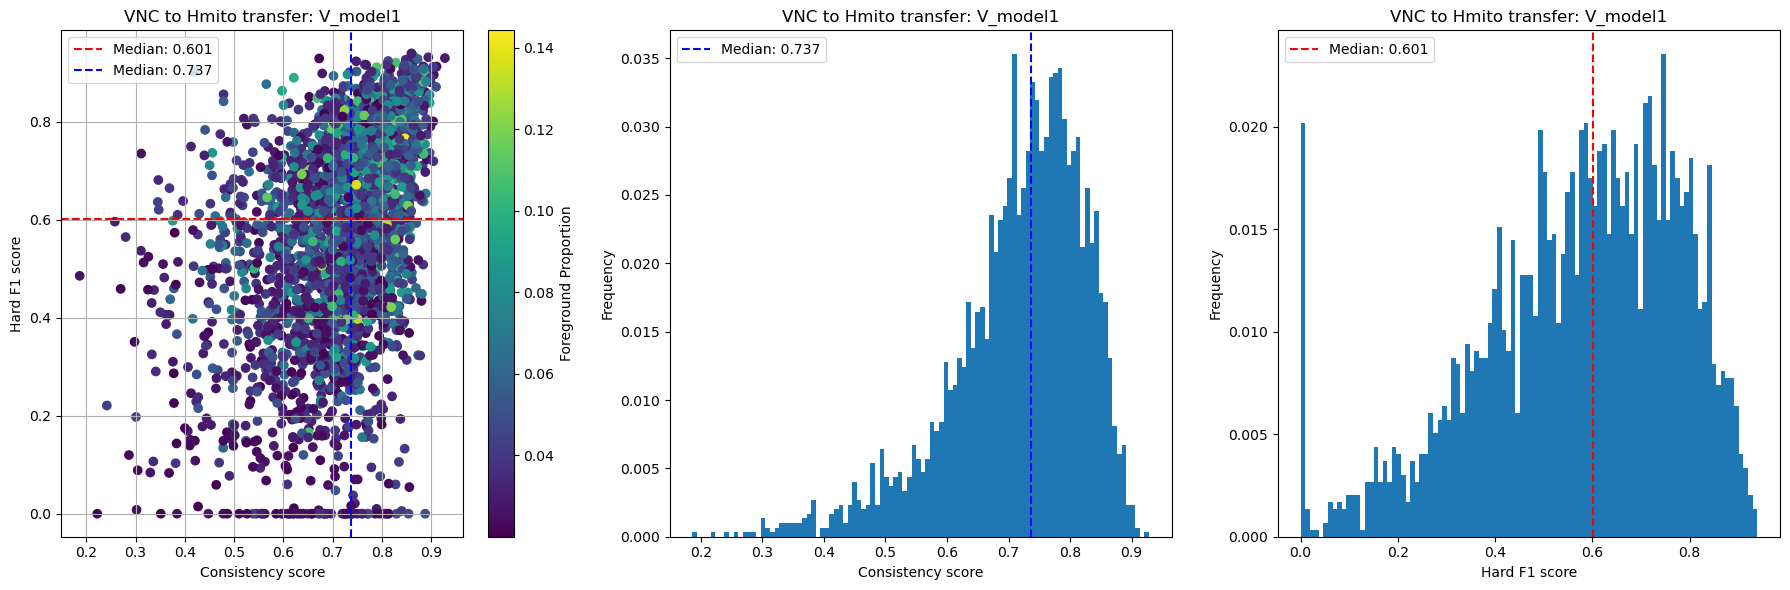

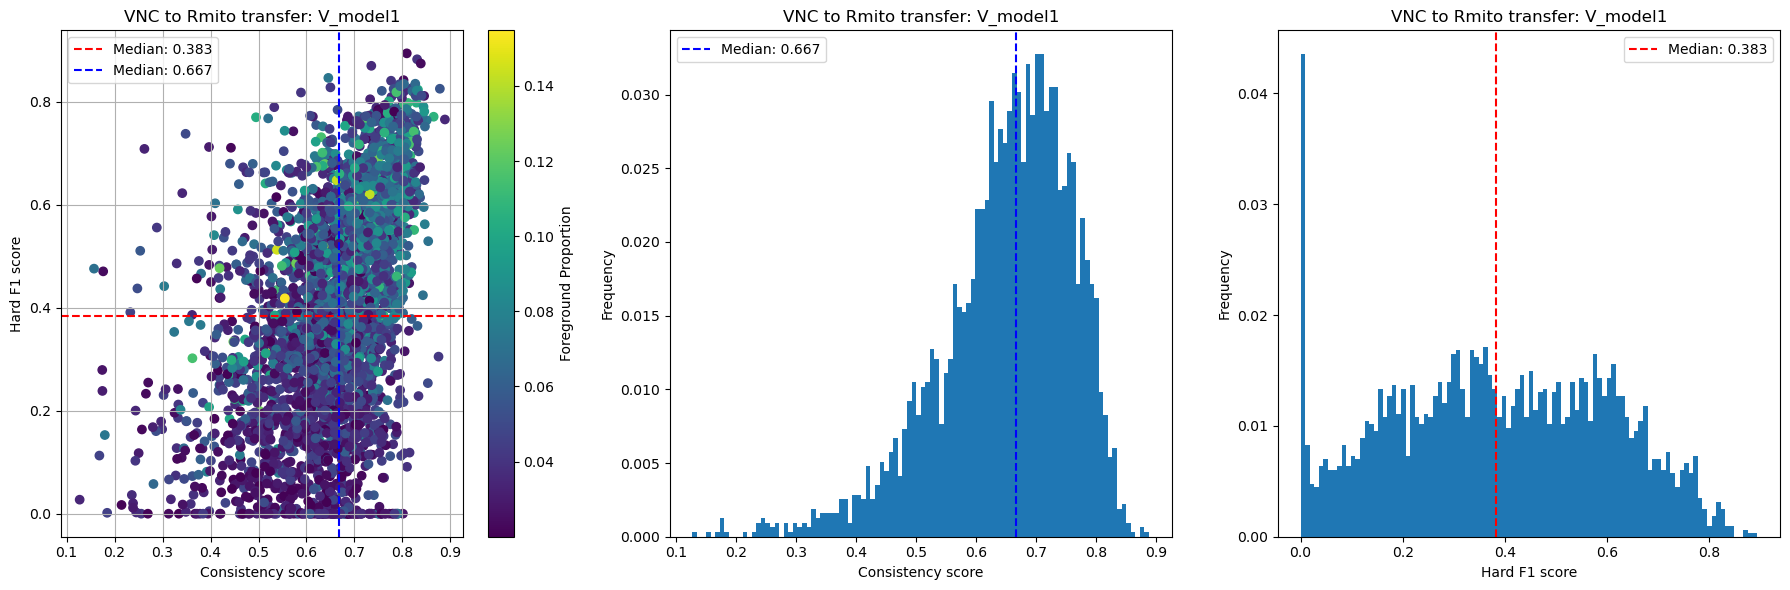

In [ ]:
sources = {
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["VNC"]
foreground_thresholds = {
    "EPFL": 0.04,
    "Hmito": 0.04,
    "Rmito": 0.04,
    "VNC": 0.02,
}


for source, model_name in sources.items():
    for target in targets:
        if source == target:
            continue
        if target == "VNC":
            result_folder = "resized"
            consis_key = "EI_consis"
            
        else:
            result_folder = "FP_3"
            if source == "VNC":
                consis_key = "EI_consis"
            else:
                consis_key = "EI_th05"
        none_paths = get_output_paths(
            source, 
            target, 
            {"none": []}, 
            [None], 
            model_name, 
            "predictions", 
            result_folder =result_folder, 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        DO_paths = get_output_paths(
            source, 
            target, 
            {"DO": ["a02"]}, 
            [None], 
            model_name, 
            "predictions", 
            result_folder =result_folder, 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(none_paths) == 1, f"Expected one path for {source} to {target} transfer: {model_name}, found {len(paths)}"
        direct_pred_path: List[Path] = list(Path(none_paths[0]).glob("*.h5"))
        DO_pred_path: List[Path] = list(Path(DO_paths[0]).glob("*.h5"))
        for i in range(len(direct_pred_path)):
            if "metric_summary" in direct_pred_path[i].name:
                _ = direct_pred_path.pop(i)
            if "metric_summary" in DO_pred_path[i].name:
                _ = DO_pred_path.pop(i)
        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")[:,1]
        consis_score_direct = load_h5(DO_pred_path[0], consis_key)
        consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))
        foreground_proportions = np.count_nonzero(~np.isnan(consis_score_direct), axis=(1,2))/consis_score_direct[0].size
        if foreground_proportions is not None:
            sel_ids = np.where(foreground_proportions > foreground_thresholds[source])[0]
            consis_score_PP = consis_score_PP[sel_ids]
            eval_score_direct = eval_score_direct[sel_ids]
            foreground_proportions = foreground_proportions[sel_ids]
            eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
            consis_median = np.nanmedian(consis_score_PP, axis=0)
        else:
            eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
            consis_median = np.nanmedian(consis_score_PP, axis=0)
        _, axs = plt.subplots(1, 3, figsize=(18, 6))
        sc = axs[0].scatter(consis_score_PP, eval_score_direct, c=foreground_proportions, cmap='viridis')
        _ = axs[0].set_xlabel("Consistency score")
        plt.colorbar(sc, ax=axs[0], label='Foreground Proportion')
        _ = axs[0].set_ylabel("Hard F1 score")
        _ = axs[0].grid()
        _ = axs[0].set_title(f"{source} to {target} transfer: {model_name}")
        _ = axs[0].axhline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
        _ = axs[0].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
        _ = axs[0].legend()
        _ = axs[1].hist(consis_score_PP, bins=100, weights=np.ones_like(consis_score_PP) / len(consis_score_PP))
        _ = axs[1].set_title(f"{source} to {target} transfer: {model_name}")
        _ = axs[1].set_xlabel("Consistency score")
        _ = axs[1].set_ylabel("Frequency")
        _ = axs[1].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
        _ = axs[1].legend()
        _ = axs[2].hist(eval_score_direct, bins=100, weights=np.ones_like(eval_score_direct) / len(eval_score_direct))
        _ = axs[2].axvline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
        _ = axs[2].legend()
        _ = axs[2].set_title(f"{source} to {target} transfer: {model_name}")
        _ = axs[2].set_xlabel("Hard F1 score")
        _ = axs[2].set_ylabel("Frequency")
        plt.tight_layout()
        plt.show()
        

# Correlation Scores

In [2]:
from numpy.typing import NDArray
from typing import Any
from tqdm import tqdm

from model_ranking import (
    permutation_test_kendall_tau,
    scores_to_rank,
)

In [3]:
sources = {
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}
targets = ["EPFL", "Hmito", "Rmito", "VNC"]


eval_scores_per_transfer: Dict[str, NDArray[Any]] = {}
consis_scores_per_transfer: Dict[str, NDArray[Any]] = {}
foreground_proportions_per_transfer: Dict[str, NDArray[Any]] = {}

for source, model_name in sources.items():
    for target in targets:
        if source == target:
            continue
        if target == "VNC":
            result_folder = "resized"
            consis_key = "EI_consis"
            
        else:
            result_folder = "FP_3"
            if source == "VNC":
                consis_key = "EI_consis"
            else:
                consis_key = "EI_th05"
        none_paths = get_output_paths(
            source, 
            target, 
            {"none": []}, 
            [None], 
            model_name, 
            "predictions", 
            result_folder =result_folder, 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        DO_paths = get_output_paths(
            source, 
            target, 
            {"DO": ["a02"]}, 
            [None], 
            model_name, 
            "predictions", 
            result_folder =result_folder, 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(none_paths) == 1, f"Expected one path for {source} to {target} transfer: {model_name}, found {len(paths)}"
        direct_pred_path: List[Path] = list(Path(none_paths[0]).glob("*.h5"))
        DO_pred_path: List[Path] = list(Path(DO_paths[0]).glob("*.h5"))
        for i in range(len(direct_pred_path)):
            if "metric_summary" in direct_pred_path[i].name:
                _ = direct_pred_path.pop(i)
            if "metric_summary" in DO_pred_path[i].name:
                _ = DO_pred_path.pop(i)

        # Load the evaluation and consistency scores
        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")[:,1]
        consis_score_direct = load_h5(DO_pred_path[0], consis_key)
        consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))
        # Calculate foreground proportions
        foreground_proportions = np.count_nonzero(~np.isnan(consis_score_direct), axis=(1,2))/consis_score_direct[0].size

        # Save the scores for each transfer
        eval_scores_per_transfer[f"{source}_to_{target}"] = eval_score_direct
        consis_scores_per_transfer[f"{source}_to_{target}"] = consis_score_PP
        foreground_proportions_per_transfer[f"{source}_to_{target}"] = foreground_proportions

/tmp/ipykernel_3665313/720803573.py:60: RuntimeWarning: Mean of empty slice
  consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))


In [4]:

foreground_thresholds = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1]
#targets = ["VNC"]
correlations_per_transfer: Dict[str, List[float]] = {
    "EPFL_to_Hmito": [],
    "EPFL_to_Rmito": [],
    "EPFL_to_VNC": [],
    "Hmito_to_EPFL": [],
    "Hmito_to_Rmito": [],
    "Hmito_to_VNC": [],
    "Rmito_to_EPFL": [],
    "Rmito_to_Hmito": [],
    "Rmito_to_VNC": [],
    "VNC_to_EPFL": [],
    "VNC_to_Hmito": [],
    "VNC_to_Rmito": [],
}

for foreground_threshold in tqdm(foreground_thresholds):
    for transfer, eval_score_direct in eval_scores_per_transfer.items():
        consis_score_PP = consis_scores_per_transfer[transfer]
        foreground_proportions = foreground_proportions_per_transfer[transfer]

        ids_foreground = np.where(foreground_proportions > foreground_threshold)[0]
        if len(ids_foreground) == 0:
            print(f"No foreground pixels above threshold {foreground_threshold} for transfer {transfer}. Skipping.")
            continue

        eval_scores_th = eval_score_direct[ids_foreground]
        consis_scores_th = consis_score_PP[ids_foreground]

        eval_rank = scores_to_rank(eval_scores_th, ascending=False)
        consis_rank = scores_to_rank(consis_scores_th, ascending=False)
        ktau, pval = permutation_test_kendall_tau(eval_rank, consis_rank)
        correlations_per_transfer[transfer].append(ktau)
        #print(f"Transfer: {transfer}, Kendall's tau: {ktau}, p-value: {pval}")
        

  0%|          | 0/7 [00:00<?, ?it/s]

 14%|█▍        | 1/7 [01:11<07:09, 71.64s/it]/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/scipy/stats/_resampling.py:1467: RuntimeWarning: overflow encountered in scalar power
  n_max = factorial(n_obs_sample)**n_samples
 86%|████████▌ | 6/7 [03:01<00:18, 18.75s/it]

No foreground pixels above threshold 0.1 for transfer EPFL_to_VNC. Skipping.


100%|██████████| 7/7 [03:04<00:00, 26.40s/it]


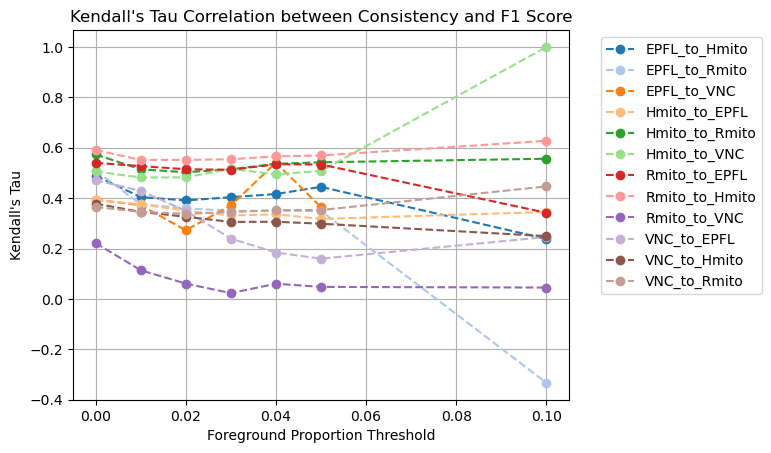

In [5]:
for transfer, correlations in correlations_per_transfer.items():
    if transfer == "EPFL_to_VNC":
        foreground_ths = foreground_thresholds[:-1]
    else:
        foreground_ths = foreground_thresholds
    cmap = plt.get_cmap('tab20')
    color = cmap(list(correlations_per_transfer.keys()).index(transfer) % 20)
    _ = plt.plot(foreground_ths, correlations, label=transfer, linestyle='--', marker='o', color=color)
_ = plt.xlabel("Foreground Proportion Threshold")
_ = plt.ylabel("Kendall's Tau")
_ = plt.title("Kendall's Tau Correlation between Consistency and F1 Score")
plt.grid()
_ =plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()